在此,我要构建两个神经网络,把宏观模型预测的值作为新的输入,与涨幅因素连接起来.看看是否能起到更好的效果.

实现 **先预测,再修正** 

| 方法 | 思路 | 与你的想法的关系 |
|---|---|---|
| 堆叠泛化，Stacking | 把第一层预测作为第二层的输入，由第二层输出最终预测 | 对应“预测的价值作为新输入” |
| 残差修正，Residual correction | 第一层先预测，第二层预测第一层会错多少，最后相加 | 对应“预测＋修正” |

| 组别 | 设计 | 要回答的问题 |
|---|---|---|
| A | 原7变量基础模型 | 原模型水平是多少？ |
| B | 7变量＋4个涨幅，一层模型 | 直接加涨幅是否已经足够？ |
| C | 第一层预测＋简单线性校准，不含涨幅 | 改善是否只是纠正整体偏高、偏低？ |
| D | 第一层＋涨幅残差修正，不含交互项 | 涨幅能否解释剩余误差？ |
| E | D加入“基础预测×涨幅”交互项 | 涨幅的作用是否取决于基础预测水平？ |
| F | 第一层＋小型神经网络修正 | 更复杂的非线性是否带来额外收益？ |

# 两阶段堆叠模型与单阶段基准：2020年测试，三个种子

本节是实际执行方案；上方其他模型组合保留为历史设想，本次只比较两组。

- **Base**：原7个宏观/价格变量 → 16 → ReLU → 32 → ReLU → 预测股价。
- **Stacking**：冻结上述Base，将其预测股价与金、铜各3个涨幅合并 → 16 → ReLU → 32 → ReLU → 最终股价。第二阶段直接预测股价，不是预测残差。
- 金、铜分别构造 `P(t)/P(t-1)-1`、`P(t)/MA5(t)-1`、`P(t)/MA20(t)-1`，滚动均值包含当日。日指原数据相邻记录，窗口为5/20条记录。
- **按用户要求不用折外预测**：第二阶段用第一阶段对同一训练集的样本内预测，充分利用可用训练数据；第一阶段冻结，两个阶段各训练100轮。
- 训练集为2020年以前，测试集仅2020年。共同剔除涨幅窗口不足或缺失的记录，两个阶段和基准使用相同有效日期。2021年以后不参与本次实验。
- 种子42、7、123；ReLU、Adam、学习率0.01、全批量、标准化目标MSE训练，按原股价尺度计算MAPE（百分数，越低越好）。所有标准化器仅拟合训练集。
- “单阶段”基准本身也有16和32两个隐藏层。堆叠第一阶段直接复用对应种子的基准，保证比较一致。

沿用原数据**同日股价**目标：这不是次日预测。样本内堆叠可能使训练误差偏乐观，结论以2020年测试误差为准，不使用测试集选择轮数或种子。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_OUT', str(ROOT/'results/mlp_stacking_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2035,2012-06-05,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
history=[]
def fit_model(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad()
        loss=((model(xt)-yt)**2).mean(); assert torch.isfinite(loss)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): mse=((model(xt)-yt)**2).mean().item()
        history.append(dict(Seed=seed,Stage=label,Epoch=epoch,Train_MSE=mse))
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle
    model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel(); assert np.isfinite(p).all()
    return p

def save_model(bundle,seed,label,features):
    model,sx,sy=bundle
    torch.save(dict(state_dict=model.state_dict(),features=features,seed=seed,epochs=EPOCHS,
                    sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),
                    sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist(),
                    train_start=str(tr.min()),train_end=str(tr.max())),OUT/f'{label}_seed{seed}.pt')

rows=[]; frames=[]
for seed in SEEDS:
    base=fit_model(x.loc[tr,BASE],y.loc[tr],seed,'Base')
    bp=pd.Series(predict(base,x[BASE]),index=x.index)
    # 用户指定：全训练集样本内预测；不做折外划分、不反向更新第一阶段。
    meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
    stack=fit_model(meta.loc[tr],y.loc[tr],seed,'Stage2')
    sp=pd.Series(predict(stack,meta),index=x.index)
    save_model(base,seed,'Base',BASE); save_model(stack,seed,'Stage2',list(meta.columns))
    meta.to_csv(OUT/f'stage2_inputs_seed{seed}.csv',index_label='Date')
    for model,pred in [('Base',bp),('Stacking',sp)]:
        for split,idx in [('Train',tr),('Test',te)]:
            actual=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy()
            ape=100*np.abs(p-actual)/np.abs(actual)
            rows.append(dict(Seed=seed,Model=model,Split=split,N=len(idx),MAPE=ape.mean()))
            frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Model=model,Split=split,Actual=actual,Predicted=p,APE=ape)))
    print(f'Seed {seed}: two stages completed, each {EPOCHS} epochs')
metrics=pd.DataFrame(rows); predictions=pd.concat(frames,ignore_index=True)
history=pd.DataFrame(history)
metrics.to_csv(OUT/'metrics.csv',index=False)
predictions.to_csv(OUT/'predictions.csv',index=False)
history.to_csv(OUT/'training_history.csv',index=False)
test=metrics[metrics.Split=='Test']
comparison=test.pivot(index='Seed',columns='Model',values='MAPE').reindex(SEEDS)
comparison['Stacking_minus_Base_pp']=comparison.Stacking-comparison.Base
summary=test.groupby('Model').MAPE.agg(['mean','std','min','max']).reindex(['Base','Stacking'])
comparison.to_csv(OUT/'seed_comparison.csv'); summary.to_csv(OUT/'summary.csv')
assert len(metrics)==12 and len(history)==3*2*100
assert predictions.groupby(['Seed','Model','Split']).size().nunique()==2
print('2020 Test MAPE (%); negative paired difference means stacking improves')
display(comparison.round(4)); display(summary.round(4))
print('Train MAPE (%), based on in-sample predictions:')
display(metrics[metrics.Split=='Train'].pivot(index='Seed',columns='Model',values='MAPE').reindex(SEEDS).round(4))


Model,Base,Stacking,Stacking_minus_Base_pp
Seed,,,
42,12.7949,12.9362,0.1412
7,10.5378,10.4800,-0.0578
123,16.1385,15.9172,-0.2213


,mean,std,min,max
Model,,,,
Base,13.1571,2.8179,10.5378,16.1385
Stacking,13.1111,2.7228,10.4800,15.9172


Model,Base,Stacking
Seed,,
42,2.7657,2.7997
7,2.9166,2.7380
123,2.8893,2.7271


Seed 42: two stages completed, each 100 epochs
Seed 7: two stages completed, each 100 epochs
Seed 123: two stages completed, each 100 epochs
2020 Test MAPE (%); negative paired difference means stacking improves
Train MAPE (%), based on in-sample predictions:


## 预测曲线与训练过程

每个种子单独画出2020年预测；汇总值是三个种子的MAPE均值与样本标准差，并非先平均预测再算MAPE。配对差为堆叠MAPE减基准MAPE，负数表示堆叠改善。

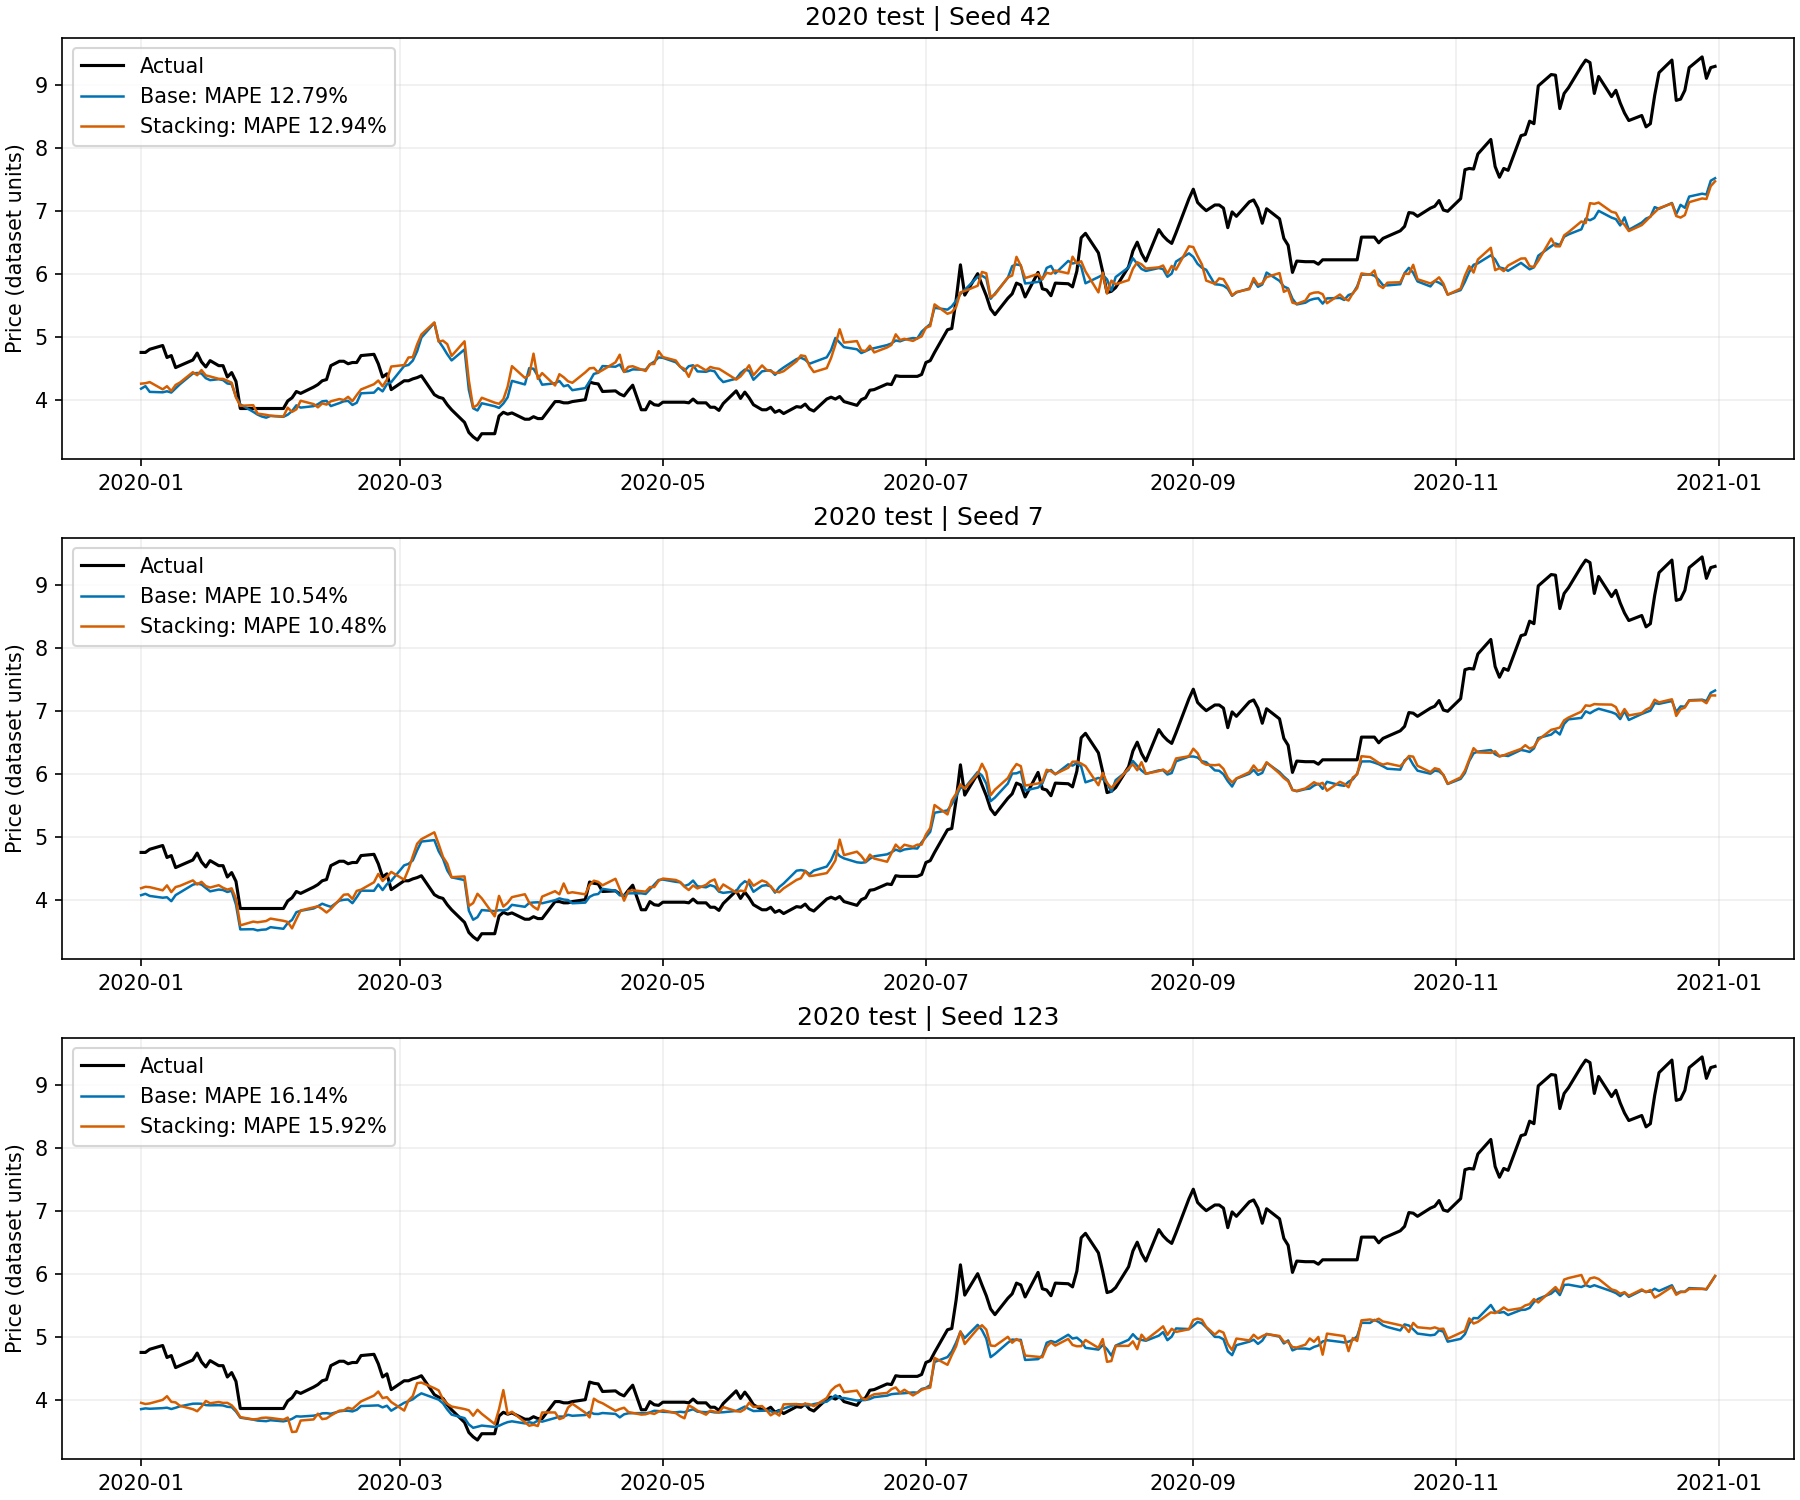

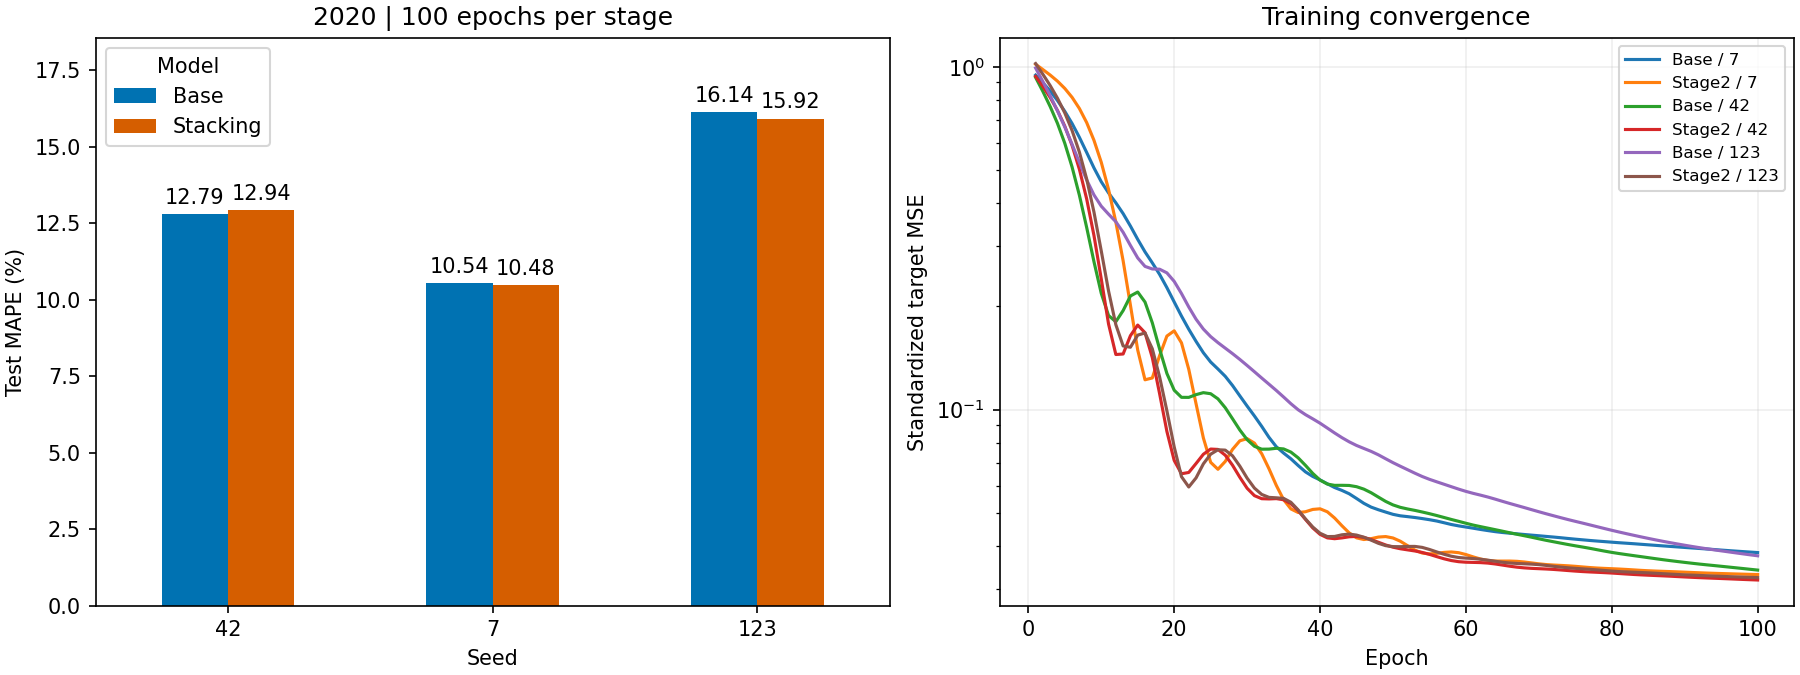

堆叠模型在2/3个种子中测试MAPE更低；平均配对差为-0.0459个百分点。
单个测试年、三个种子只能说明本次设定下的结果，不能据此证明其他年份也更好。


In [3]:
fig,axes=plt.subplots(3,1,figsize=(12,10),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.plot(te,y.loc[te],color='black',lw=1.5,label='Actual')
    for name,color in [('Base','#0072B2'),('Stacking','#D55E00')]:
        g=predictions[(predictions.Seed==seed)&(predictions.Model==name)&(predictions.Split=='Test')]
        ax.plot(g.Date,g.Predicted,color=color,lw=1.2,label=f'{name}: MAPE {comparison.loc[seed,name]:.2f}%')
    ax.set(title=f'2020 test | Seed {seed}',ylabel='Price (dataset units)'); ax.legend(); ax.grid(alpha=.2)
fig.savefig(OUT/'predictions_2020.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'predictions_2020.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
comparison[['Base','Stacking']].plot.bar(ax=axes[0],rot=0,color=['#0072B2','#D55E00'])
axes[0].set(ylabel='Test MAPE (%)',title='2020 | 100 epochs per stage')
for c in axes[0].containers: axes[0].bar_label(c,fmt='%.2f',padding=3)
axes[0].margins(y=.15)
for (seed,stage),g in history.groupby(['Seed','Stage']):
    axes[1].plot(g.Epoch,g.Train_MSE,label=f'{stage} / {seed}')
axes[1].set(xlabel='Epoch',ylabel='Standardized target MSE',yscale='log',title='Training convergence')
axes[1].legend(fontsize=8); axes[1].grid(alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'comparison.png')))
monthly=predictions[predictions.Split=='Test'].copy()
monthly['Month']=monthly.Date.dt.strftime('%Y-%m')
monthly=monthly.groupby(['Month','Seed','Model']).APE.mean().unstack('Model')
monthly.to_csv(OUT/'monthly_mape.csv')
mean_delta=comparison.Stacking_minus_Base_pp.mean()
wins=int((comparison.Stacking_minus_Base_pp<0).sum())
print(f'堆叠模型在{wins}/3个种子中测试MAPE更低；平均配对差为{mean_delta:+.4f}个百分点。')
print('单个测试年、三个种子只能说明本次设定下的结果，不能据此证明其他年份也更好。')


## 本次运行结果

| 随机种子 | 基准MAPE (%) | 堆叠MAPE (%) | 堆叠−基准（百分点） |
|---|---:|---:|---:|
|42|12.7949|12.9362|+0.1412|
|7|10.5378|10.4800|−0.0578|
|123|16.1385|15.9172|−0.2213|
|均值|13.1571|13.1111|−0.0459|

三个种子的样本标准差：基准2.8179、堆叠2.7228个百分点。堆叠在2/3个种子上改善，但平均改善仅0.0459个百分点，远小于种子之间的差异，**本次结果未显示明显、稳定的优势**。

训练样本2035条（2012-06-05至2019-12-31），测试样本271条（2020-01-01至2020-12-31）。样本沿用原Dataset的日期对齐，不能把271条直接称为271个A股交易日。没有折外预测，所有有效训练样本都用于两个阶段。


# 堆叠模型训练轮数对比：100 / 200 / 400 / 800

保持前一实验的训练/测试日期、原7个基准输入、金铜6项涨幅、16×32隐藏层、ReLU、Adam学习率0.01、全批量、种子42/7/123不变。**不用折外预测**，第二阶段使用第一阶段对全部有效训练样本的样本内预测。

每组轮数E表示：**第一阶段训练E轮，冻结后生成预测，第二阶段从相同种子的初始状态训练E轮**。第一阶段在同一800轮训练路径上保存四个检查点；不同E的第二阶段因输入预测不同，独立初始化训练。每组总计2E轮，不是两个阶段合计E轮。

2020年为固定测试集；报告所有预先指定轮数，不使用测试集早停或挑选种子。第一阶段基准结果也保留，便于判断第二阶段是否改善。以下单元可单独从本节起运行。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_EPOCH_OUT', str(ROOT/'results/mlp_stacking_epochs_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2035,2012-06-05,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
import copy
BUDGETS=[100,200,400,800]
config['epoch_budgets_per_stage']=BUDGETS
config.pop('epochs_per_stage',None)
config['stage1_path']='shared checkpoints within seed'
config['stage2_path']='fresh fit for each budget using corresponding stage1 predictions'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def train_checkpoints(X,Y,seed,stage,budget,checkpoints):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR); saved={}
    for epoch in range(1,max(checkpoints)+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): mse=((model(xt)-yt)**2).mean().item()
        H.append(dict(Seed=seed,Stage=stage,Budget=budget,Epoch=epoch,Train_MSE=mse))
        if epoch in checkpoints: saved[epoch]=(copy.deepcopy(model),sx,sy)
    return saved

def predict_e(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

def save_e(bundle,seed,stage,budget,features):
    model,sx,sy=bundle
    torch.save(dict(state_dict=model.state_dict(),features=features,seed=seed,epochs=budget,
        hidden=[16,32],sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),
        sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist(),
        train_start=str(tr.min()),train_end=str(tr.max())),OUT/f'{stage}_{budget}_seed{seed}.pt')

rows=[]; frames=[]
for seed in SEEDS:
    bases=train_checkpoints(x.loc[tr,BASE],y.loc[tr],seed,'Base',800,BUDGETS)
    for budget in BUDGETS:
        base=bases[budget]; bp=predict_e(base,x[BASE])
        meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
        stack=train_checkpoints(meta.loc[tr],y.loc[tr],seed,'Stage2',budget,[budget])[budget]
        sp=predict_e(stack,meta)
        save_e(base,seed,'Base',budget,BASE); save_e(stack,seed,'Stage2',budget,list(meta.columns))
        for name,pred in [('Base',bp),('Stacking',sp)]:
            for split,idx in [('Train',tr),('Test',te)]:
                actual=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy()
                ape=100*np.abs(p-actual)/np.abs(actual)
                rows.append(dict(Seed=seed,Epochs=budget,Model=name,Split=split,N=len(idx),MAPE=ape.mean()))
                frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Epochs=budget,Model=name,Split=split,Actual=actual,Predicted=p,APE=ape)))
        print(f'Seed {seed}, {budget} epochs per stage completed',flush=True)
metrics_e=pd.DataFrame(rows); predictions_e=pd.concat(frames,ignore_index=True); history_e=pd.DataFrame(H)
metrics_e.to_csv(OUT/'metrics.csv',index=False)
predictions_e.to_csv(OUT/'predictions.csv',index=False)
history_e.to_csv(OUT/'training_history.csv',index=False)
assert len(metrics_e)==3*4*2*2
assert history_e.groupby(['Seed','Stage','Budget']).Epoch.max().tolist().count(800)==6
# 复核100轮与此前实验完全一致（若此前结果存在）。
prior=OUT.parent/'mlp_stacking_11/predictions.csv'
if prior.exists():
    old=pd.read_csv(prior,parse_dates=['Date'])
    new=predictions_e[predictions_e.Epochs==100]
    check=old.merge(new,on=['Date','Seed','Model','Split'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==len(old)==len(new)
    assert np.allclose(check.Actual_old,check.Actual_new,rtol=0,atol=1e-10)
    delta=np.max(np.abs(check.Predicted_old-check.Predicted_new))
    assert delta<1e-4
    print(f'100轮复现检查通过，最大预测差={delta:.8g}')
stack_metrics=metrics_e[metrics_e.Model=='Stacking']
comparison_e=stack_metrics[stack_metrics.Split=='Test'].pivot(index='Seed',columns='Epochs',values='MAPE').reindex(SEEDS)
summary_e=stack_metrics.groupby(['Epochs','Split']).MAPE.agg(['mean','std','min','max'])
paired_e=metrics_e[metrics_e.Split=='Test'].pivot(index=['Epochs','Seed'],columns='Model',values='MAPE')
paired_e['Stacking_minus_Base_pp']=paired_e.Stacking-paired_e.Base
comparison_e.to_csv(OUT/'test_mape_by_seed.csv'); summary_e.to_csv(OUT/'summary.csv'); paired_e.to_csv(OUT/'paired_comparison.csv')
print('堆叠模型2020测试MAPE (%)：'); display(comparison_e.round(4))
print('堆叠模型训练/测试MAPE均值及样本标准差：'); display(summary_e.round(4))
print('同轮数堆叠与第一阶段基准的测试对比：'); display(paired_e.round(4))


Epochs,100,200,400,800
Seed,,,,
42,12.9362,13.3050,12.5285,17.8292
7,10.4800,9.7845,15.6741,24.8620
123,15.9172,15.8298,19.3820,25.8067


mean     std      min      max
Epochs Split                                   
100    Test   13.1111  2.7228  10.4800  15.9172
       Train   2.7549  0.0392   2.7271   2.7997
200    Test   12.9731  3.0363   9.7845  15.8298
       Train   2.2930  0.0327   2.2611   2.3264
400    Test   15.8615  3.4306  12.5285  19.3820
       Train   1.9246  0.0414   1.8857   1.9680
800    Test   22.8326  4.3588  17.8292  25.8067
       Train   1.6387  0.0521   1.6051   1.6988

Model           Base  Stacking  Stacking_minus_Base_pp
Epochs Seed                                           
100    7     10.5378   10.4800                 -0.0578
       42    12.7949   12.9362                  0.1412
       123   16.1385   15.9172                 -0.2213
200    7      9.6727    9.7845                  0.1117
       42    13.3132   13.3050                 -0.0082
       123   15.6207   15.8298                  0.2091
400    7     15.5907   15.6741                  0.0834
       42    12.5932   12.5285                 -0.0647
       123   19.2906   19.3820                  0.0914
800    7     25.0359   24.8620                 -0.1739
       42    17.6403   17.8292                  0.1889
       123   25.6648   25.8067                  0.1419

Seed 42, 100 epochs per stage completed
Seed 42, 200 epochs per stage completed
Seed 42, 400 epochs per stage completed
Seed 42, 800 epochs per stage completed
Seed 7, 100 epochs per stage completed
Seed 7, 200 epochs per stage completed
Seed 7, 400 epochs per stage completed
Seed 7, 800 epochs per stage completed
Seed 123, 100 epochs per stage completed
Seed 123, 200 epochs per stage completed
Seed 123, 400 epochs per stage completed
Seed 123, 800 epochs per stage completed
100轮复现检查通过，最大预测差=2.3800659e-07
堆叠模型2020测试MAPE (%)：
堆叠模型训练/测试MAPE均值及样本标准差：
同轮数堆叠与第一阶段基准的测试对比：


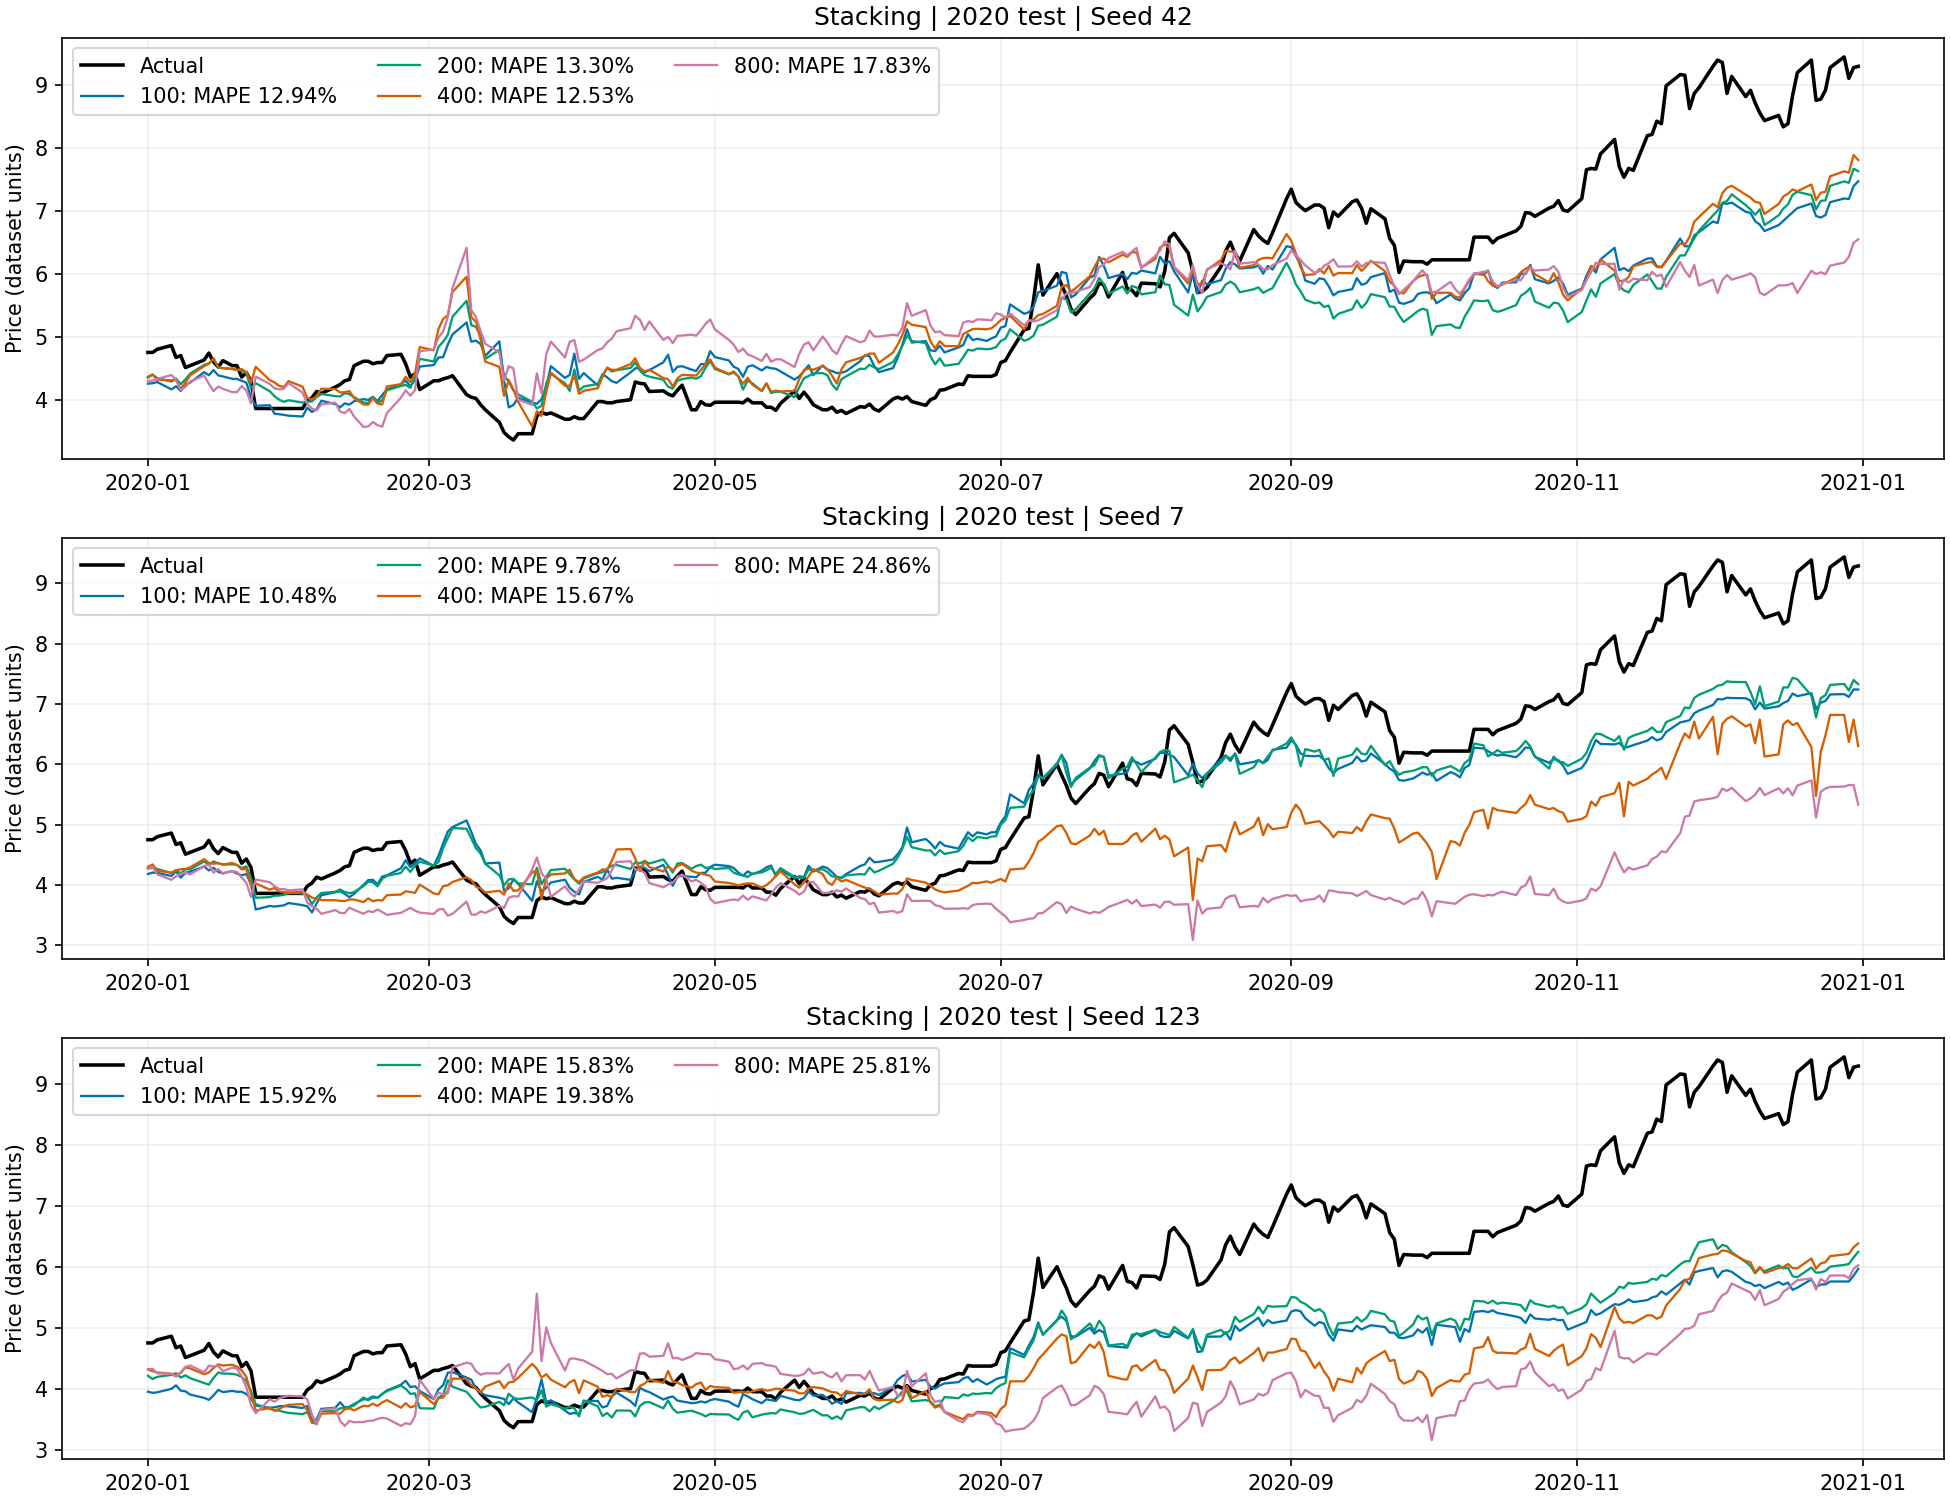

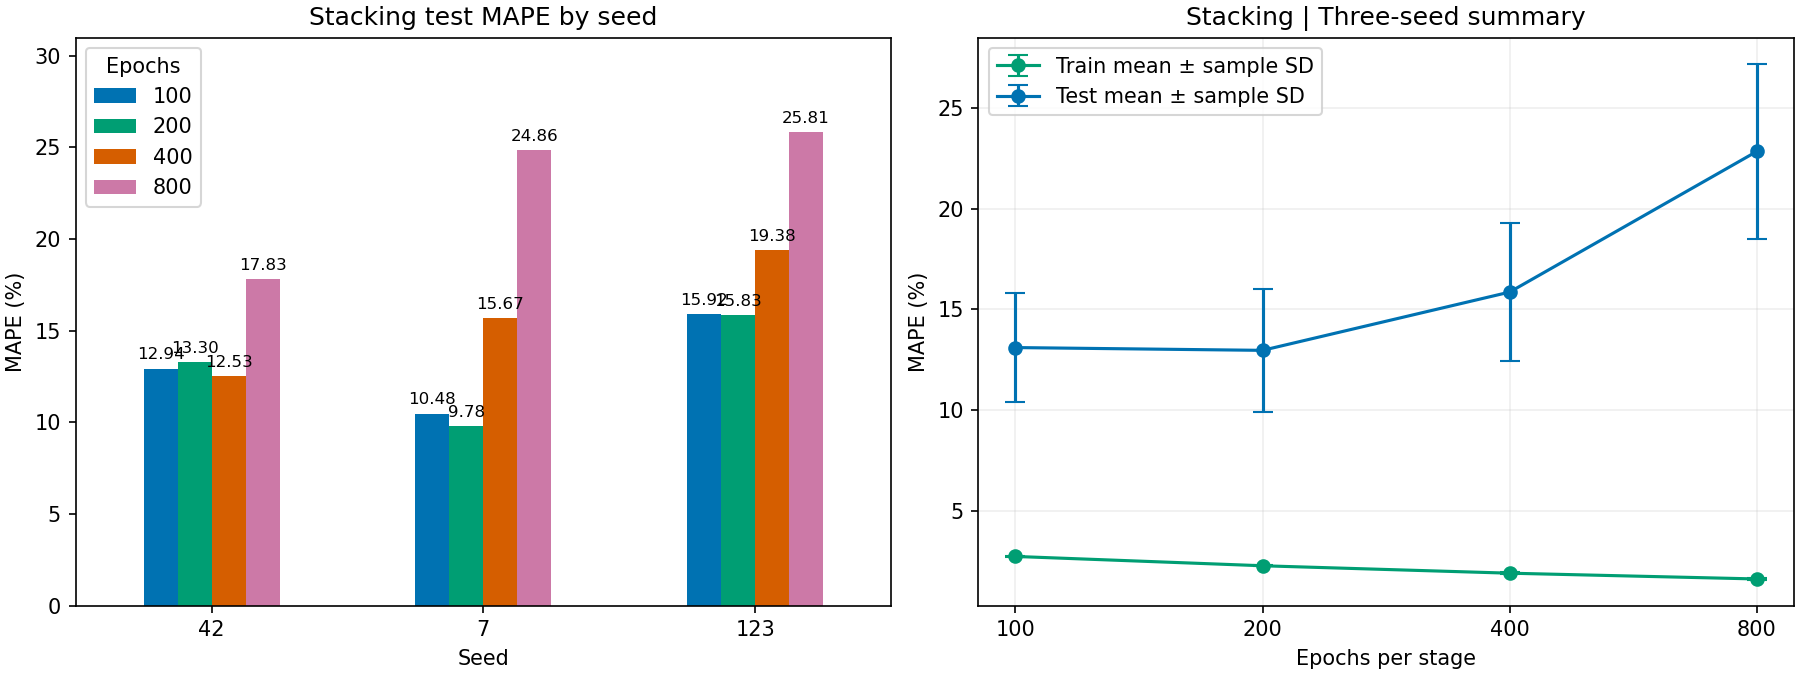

In [3]:
colors={100:'#0072B2',200:'#009E73',400:'#D55E00',800:'#CC79A7'}
fig,axes=plt.subplots(3,1,figsize=(13,10),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.plot(te,y.loc[te],color='black',lw=1.7,label='Actual')
    for budget in BUDGETS:
        g=predictions_e[(predictions_e.Seed==seed)&(predictions_e.Epochs==budget)&(predictions_e.Model=='Stacking')&(predictions_e.Split=='Test')]
        ax.plot(g.Date,g.Predicted,color=colors[budget],lw=1.1,label=f'{budget}: MAPE {comparison_e.loc[seed,budget]:.2f}%')
    ax.set(title=f'Stacking | 2020 test | Seed {seed}',ylabel='Price (dataset units)'); ax.legend(ncol=3); ax.grid(alpha=.2)
fig.savefig(OUT/'predictions_by_epochs.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'predictions_by_epochs.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
comparison_e.plot.bar(ax=axes[0],rot=0,color=[colors[e] for e in BUDGETS])
axes[0].set(title='Stacking test MAPE by seed',ylabel='MAPE (%)')
for c in axes[0].containers: axes[0].bar_label(c,fmt='%.2f',padding=3,fontsize=8)
axes[0].margins(y=.2)
for split,col in [('Train','#009E73'),('Test','#0072B2')]:
    g=summary_e.xs(split,level='Split').reindex(BUDGETS)
    axes[1].errorbar(range(4),g['mean'],yerr=g['std'],marker='o',capsize=5,color=col,label=split+' mean ± sample SD')
axes[1].set(xticks=range(4),xticklabels=BUDGETS,xlabel='Epochs per stage',ylabel='MAPE (%)',title='Stacking | Three-seed summary')
axes[1].legend(); axes[1].grid(alpha=.2)
fig.savefig(OUT/'epoch_comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'epoch_comparison.png')))
monthly=predictions_e[predictions_e.Split=='Test'].copy()
monthly['Month']=monthly.Date.dt.strftime('%Y-%m')
monthly.groupby(['Month','Seed','Epochs','Model']).APE.mean().to_csv(OUT/'monthly_mape.csv')


## 轮数对比结论

| 每阶段轮数 | seed42测试MAPE | seed7测试MAPE | seed123测试MAPE | 测试均值 | 测试样本标准差 | 训练均值 |
|---|---:|---:|---:|---:|---:|---:|
|100|12.9362%|10.4800%|15.9172%|13.1111%|2.7228个百分点|2.7549%|
|200|13.3050%|9.7845%|15.8298%|12.9731%|3.0363个百分点|2.2930%|
|400|12.5285%|15.6741%|19.3820%|15.8615%|3.4306个百分点|1.9246%|
|800|17.8292%|24.8620%|25.8067%|22.8326%|4.3588个百分点|1.6387%|

- **200轮测试均值最低，但比100轮只低0.1381个百分点**，且seed42反而变差，不能认定200轮具有稳定优势。
- 400轮较100轮平均恶化2.7504个百分点；800轮恶化9.7215个百分点，三个种子在800轮均比100轮差。
- 训练MAPE从2.7549%持续降至1.6387%，测试误差却在400、800轮上升，呈现过拟合迹象。
- 同轮数下，堆叠与第一阶段基准的每个种子测试MAPE差距均不到0.23个百分点。第二阶段未明显纠正第一阶段的测试误差；本实验同时增加两个阶段轮数，不能单独归因于第二阶段训练过久。
- 这里的200轮最低是对2020测试结果的描述，不能代替独立验证集选参。所有预设结果均保留，没有按2020年结果重新训练。

100轮预测已复核与上一实验一致（最大绝对差小于1e-4）。本节结果保存于 `results/mlp_stacking_epochs_11`，包括各轮数模型权重、逐日预测、训练过程、按月MAPE及图表。


---

经测试,采用堆叠的方式,100与200轮对比基准的100轮都是有所改进的.

# 200轮：基准、堆叠、原始输入直接加入金铜收益率

三个种子42、7、123；训练截至2019年末，2020年测试；16→32隐藏层、ReLU、Adam学习率0.01、全批量，各网络200轮。

- **Base**：原7变量→股价。
- **Stacking**：Base预测＋原有6项金铜指标（各自昨日涨幅、相对5/20期均价涨幅）→股价；两个阶段各200轮，样本内训练，不用折外预测，冻结Base。
- **DirectReturns**：原7变量＋金、铜各5/20期收益率，共11项输入→股价，单阶段200轮。此处收益率沿用10：`P(t)/P(t-k)-1`，不是相对移动均价的偏离。

三组使用完全相同的有效训练/测试日期。新增20期收益率需要20条历史，较上一实验共同少1条训练记录，因此统一重新训练，不能把本次基准数值与上一实验视为完全相同。

所有标准化器只拟合共同训练集。训练损失为标准化目标MSE，另报告还原后的原股价尺度MSE（单位为数据股价单位的平方）。各轮训练MSE均为当轮更新后计算。堆叠训练MSE指第二阶段最终输出；另保留其第一阶段曲线。三组特征集合不完全相同，本实验比较具体方案，不能单独归因于堆叠结构。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_THREE_OUT', str(ROOT/'results/mlp_three_models_200_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=200; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
DIRECT=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_return{k}'
        x[name]=raw[col]/raw[col].shift(k)-1
        DIRECT.append(name)
FULL=BASE+DIRECT
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2034,2012-06-06,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
config['direct_features']=FULL
config['direct_return_formula']='P(t)/P(t-k)-1; k=5,20'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def fit3(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel()
        mse=float(np.mean((p-np.asarray(Y))**2))
        H.append(dict(Seed=seed,Model=label,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    return model,sx,sy

def pred3(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

rows=[]; frames=[]
for seed in SEEDS:
    base=fit3(x.loc[tr,BASE],y.loc[tr],seed,'Base')
    bp=pred3(base,x[BASE])
    meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
    stack=fit3(meta.loc[tr],y.loc[tr],seed,'Stacking')
    direct=fit3(x.loc[tr,FULL],y.loc[tr],seed,'DirectReturns')
    for name,bundle,X in [('Base',base,x[BASE]),('Stacking',stack,meta),('DirectReturns',direct,x[FULL])]:
        pred=pred3(bundle,X); model,sx,sy=bundle
        torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,
            sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{name}_seed{seed}.pt')
        for split,idx in [('Train',tr),('Test',te)]:
            a=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy(); mse=np.mean((p-a)**2)
            rows.append(dict(Seed=seed,Model=name,Split=split,N=len(idx),MAPE=100*np.mean(np.abs(p-a)/np.abs(a)),MSE=mse,MSE_standardized=mse/float(sy.scale_[0]**2)))
            frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Model=name,Split=split,Actual=a,Predicted=p)))
    print(f'Seed {seed}: all three models completed')
metrics3=pd.DataFrame(rows); history3=pd.DataFrame(H); predictions3=pd.concat(frames,ignore_index=True)
assert len(metrics3)==18 and len(history3)==1800
for row in metrics3[metrics3.Split=='Train'].itertuples():
    end=history3[(history3.Seed==row.Seed)&(history3.Model==row.Model)&(history3.Epoch==200)].iloc[0]
    assert np.isclose(end.Train_MSE,row.MSE,atol=1e-8)
metrics3.to_csv(OUT/'metrics.csv',index=False); history3.to_csv(OUT/'training_history.csv',index=False); predictions3.to_csv(OUT/'predictions.csv',index=False)
summary3=metrics3.groupby(['Model','Split'])[['MAPE','MSE','MSE_standardized']].agg(['mean','std'])
summary3.to_csv(OUT/'summary.csv')
order=['Base','Stacking','DirectReturns']
train_mse3=metrics3[metrics3.Split=='Train'].pivot(index='Seed',columns='Model',values='MSE').reindex(index=SEEDS,columns=order)
train_std3=metrics3[metrics3.Split=='Train'].pivot(index='Seed',columns='Model',values='MSE_standardized').reindex(index=SEEDS,columns=order)
test_mape3=metrics3[metrics3.Split=='Test'].pivot(index='Seed',columns='Model',values='MAPE').reindex(index=SEEDS,columns=order)
print('训练MSE（原股价尺度）：'); display(train_mse3.round(6))
print('训练MSE（标准化目标）：'); display(train_std3.round(6))
print('2020测试MAPE (%)：'); display(test_mape3.round(4))
display(summary3.round(6))


Model,Base,Stacking,DirectReturns
Seed,,,
42,0.013530,0.011930,0.011249
7,0.015786,0.013219,0.010748
123,0.014729,0.011729,0.012449


Model,Base,Stacking,DirectReturns
Seed,,,
42,0.025559,0.022535,0.021250
7,0.029820,0.024970,0.020303
123,0.027823,0.022155,0.023516


Model,Base,Stacking,DirectReturns
Seed,,,
42,12.4072,12.3425,19.6736
7,9.6460,9.9182,25.5400
123,14.9576,15.0874,12.7373


MAPE            ... MSE_standardized          
                          mean       std  ...             mean       std
Model         Split                       ...                           
Base          Test   12.336916  2.656479  ...         1.956791  0.960991
              Train   2.467689  0.065363  ...         0.027734  0.002132
DirectReturns Test   19.316966  6.408797  ...         6.881397  4.118044
              Train   2.232659  0.068482  ...         0.021690  0.001651
Stacking      Test   12.449362  2.586239  ...         1.990428  0.984008
              Train   2.296630  0.061119  ...         0.023220  0.001527

[6 rows x 6 columns]

Seed 42: all three models completed
Seed 7: all three models completed
Seed 123: all three models completed
训练MSE（原股价尺度）：
训练MSE（标准化目标）：
2020测试MAPE (%)：


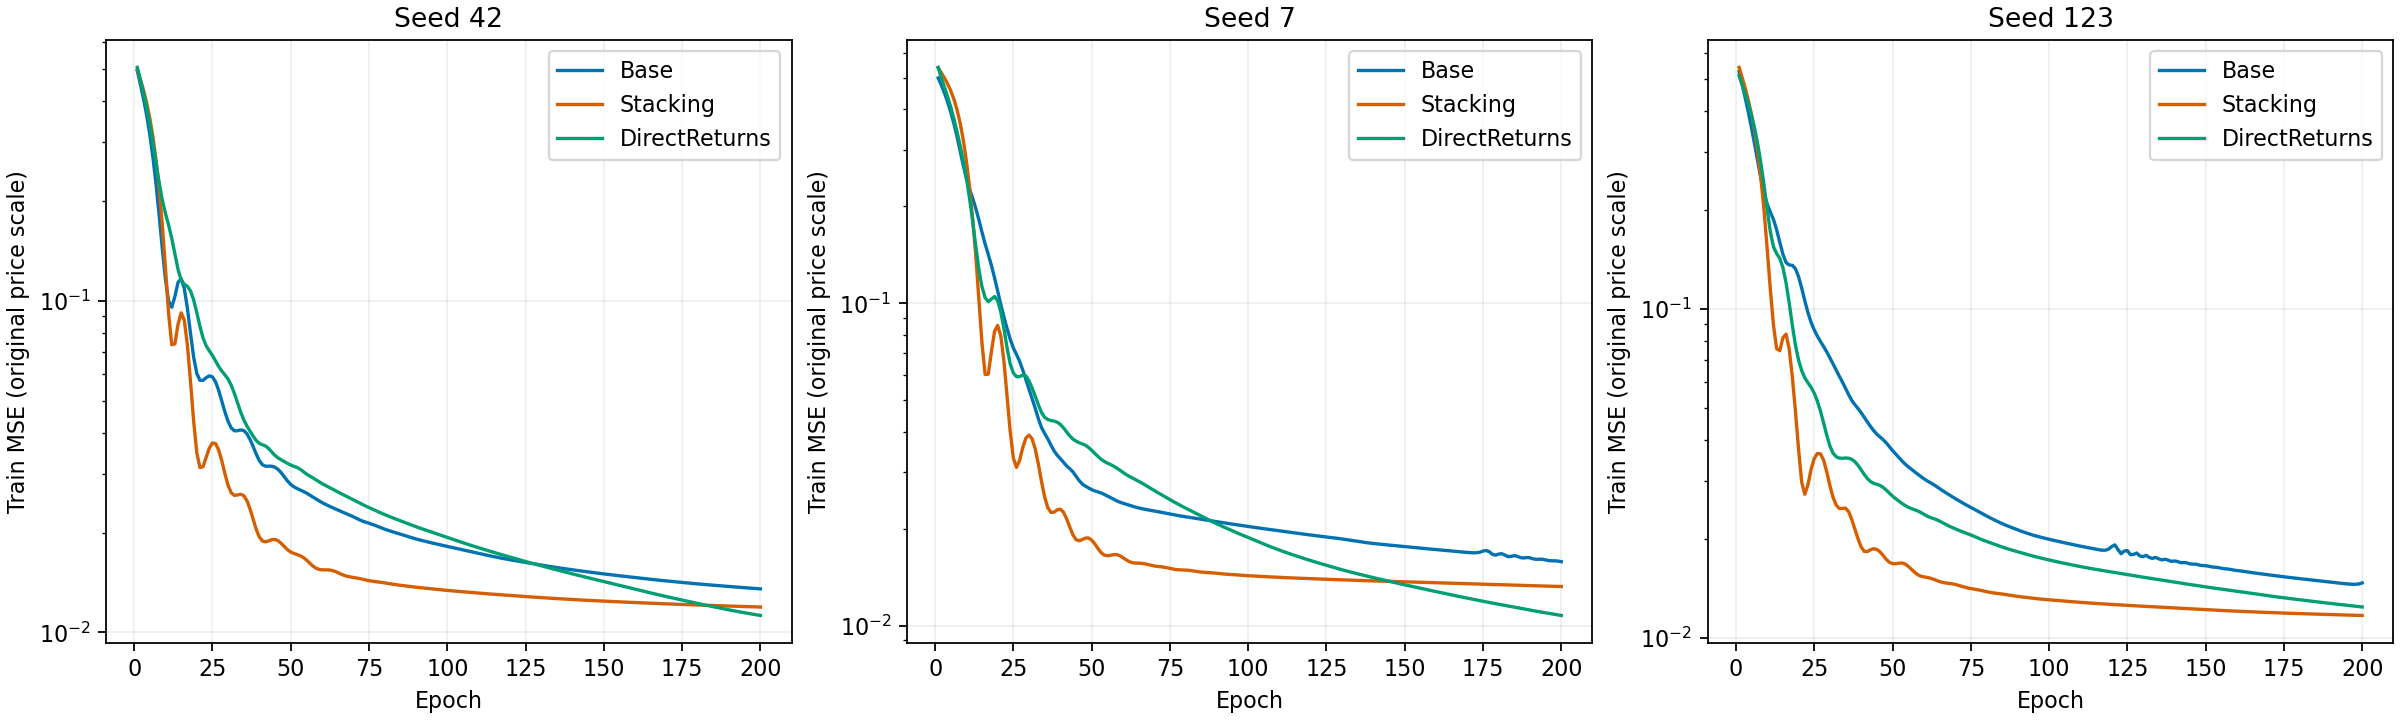

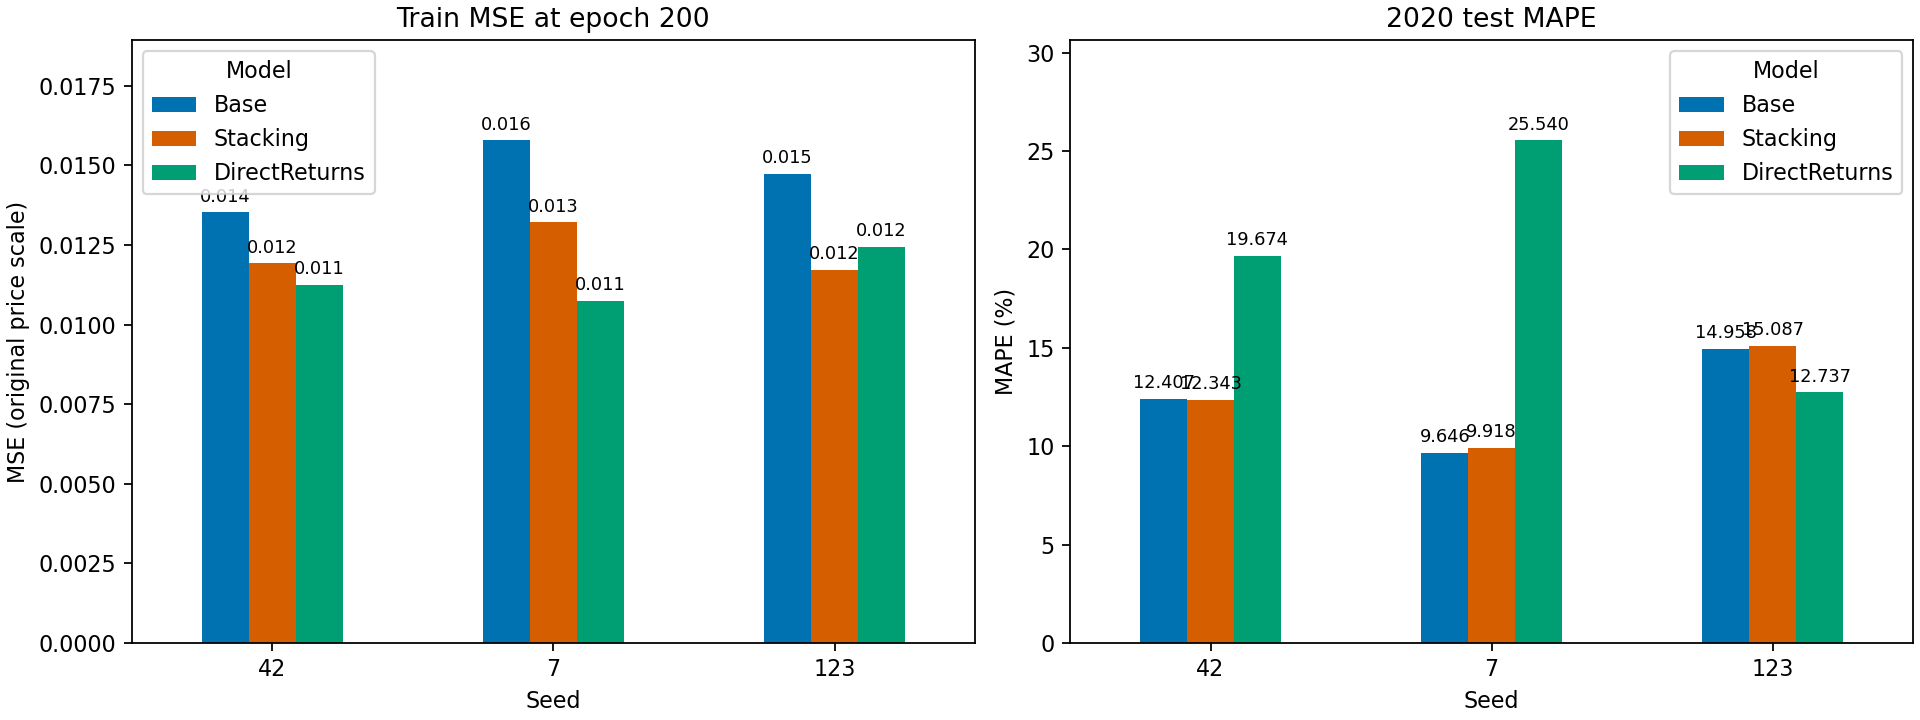

In [3]:
colors={'Base':'#0072B2','Stacking':'#D55E00','DirectReturns':'#009E73'}
fig,axes=plt.subplots(1,3,figsize=(15,4.5),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    for name in order:
        g=history3[(history3.Seed==seed)&(history3.Model==name)]
        ax.plot(g.Epoch,g.Train_MSE,color=colors[name],label=name)
    ax.set(title=f'Seed {seed}',xlabel='Epoch',ylabel='Train MSE (original price scale)',yscale='log'); ax.grid(alpha=.2); ax.legend()
fig.savefig(OUT/'training_mse.png',dpi=160); plt.close(fig)
display(Image(filename=str(OUT/'training_mse.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
for ax,table,title,ylabel in [(axes[0],train_mse3,'Train MSE at epoch 200','MSE (original price scale)'),(axes[1],test_mape3,'2020 test MAPE','MAPE (%)')]:
    table.plot.bar(ax=ax,rot=0,color=[colors[m] for m in order])
    ax.set(title=title,ylabel=ylabel); ax.margins(y=.2)
    for c in ax.containers: ax.bar_label(c,fmt='%.3f',padding=3,fontsize=8)
fig.savefig(OUT/'comparison.png',dpi=160); plt.close(fig)
display(Image(filename=str(OUT/'comparison.png')))


## 本次三方案结果

| 模型 | 平均训练MSE（原股价尺度） | 平均训练MSE（标准化） | 平均2020测试MAPE |
|---|---:|---:|---:|
|基准 Base|0.014682|0.027734|12.3369%|
|堆叠 Stacking|0.012292|0.023220|12.4494%|
|输入直接加收益率 DirectReturns|0.011482|0.021690|19.3170%|

直接加入收益率使训练MSE最低，但2020年测试MAPE平均最高，且三个种子的测试MAPE标准差为6.4088个百分点。种子123下它优于另外两组，种子42与7下则明显更差，说明效果不稳定。堆叠相较基准降低训练MSE，但平均测试MAPE略差0.1124个百分点。

因此，这次200轮对比中，拟合训练集更好并没有转化为更好的2020年预测。三组使用共同2034条训练样本、271条测试样本。与上次相比共同剔除了一条起始训练记录，标准化和优化路径随之改变；这是本次基准结果与此前不同的原因，提示模型对样本/训练路径也有一定敏感性。

训练曲线纵轴为原股价尺度MSE，采用对数坐标。堆叠曲线横轴是第二阶段的200轮，其第一阶段已先完成200轮，不能视为三组总计算量相同。基准及直接加收益率均为单阶段200轮。


---

从图中我们看到,不同的种子下堆叠的模型在训练集上收敛最快,100轮和200轮的MSE相差不多.可以减轻训练轮数过多导致的过拟合问题.  
直接将相对变化率加入一层模型,会导致训练结果极大不稳定.

不同的种子下,即使训练收敛,不同的模型可能得到相似的结果.但是学到的模型,未必适用于新的情况,可能重要性是错的.因此,3个种子得到的平均值,可能仍然不够说明问题.

## 训练的拟合水平相近,不代表外推能力接近.

### 如果效果接近,我们应该优先选择更加简单,训练更少,不同种子更稳定的方案.

___

# 十个种子：100与200轮、三种模型

沿用最近一次三模型实验的共同样本、架构和训练设置；仅修改DirectReturns的特征定义。种子预先固定为42、7、123、2024、2025、0、1、21、100、999。对每个种子分别运行100和200轮；相同种子、模型的100轮路径应与200轮路径的前100轮一致。

Base：7项原始输入；Stacking：基准预测＋6项金铜涨幅，两个阶段各E轮，样本内训练；DirectReturns：原7项＋金铜相对5/20期滚动均价的涨幅（P(t)/MA_k(t)−1，均价包含当日），单阶段E轮。训练为2020年前的2034条共同样本，测试为2020年271条，不设验证集、不早停、不按测试结果选种子。

报告训练与测试MAPE的10种子均值、样本标准差、最小和最大值，以及逐种子200轮减100轮的配对差。训练MSE采用原股价尺度。

**收敛诊断**：对每条训练路径，比较倒数第40至21轮与最后20轮的平均MSE，计算相对下降幅度。绝对变化不超过1%标记为“末段近似平台”，下降超过1%标记为“仍在下降”，上升超过1%标记为“末段上升”。这是预先定义的局部诊断，不是数学收敛证明，也不能据此保证泛化。堆叠诊断只针对对应第一阶段冻结后的第二阶段路径。


本节按要求重构，旧版已备份。滚动窗口按原数据相邻记录计数；DirectReturns仅加4项相对均价涨幅，不加昨日涨幅。为保持前后可比，仍剔除最初20条历史不足记录，三组共同样本仍为2034条训练、271条测试。旧实验和旧结果目录不覆盖。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_TEN_MA_OUT', str(ROOT/'results/mlp_ten_seeds_ma_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123,2024,2025,0,1,21,100,999]; EPOCHS=200; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
DIRECT=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_ma_deviation{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        DIRECT.append(name)
FULL=BASE+DIRECT
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
valid = valid & (x.index >= raw.index[20])
x=x.loc[valid]; y=y.loc[x.index]
assert len(x.index[x.index.year<2020])==2034
for metal in ['gold','copper']:
    for k in [5,20]:
        assert np.allclose(x[f'{metal}_ma_deviation{k}'], x[f'{metal}_vs_ma{k}'])
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2034,2012-06-06,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
config['direct_features']=FULL
config['epoch_budgets_per_stage']=[100,200]
config.pop('epochs_per_stage',None)
config['direct_return_formula']='P(t)/MA_k(t)-1; k=5,20; trailing mean includes current record'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def fit3(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel()
        mse=float(np.mean((p-np.asarray(Y))**2))
        H.append(dict(Seed=seed,Budget=EPOCHS,Model=label,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    return model,sx,sy

def pred3(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

rows=[]; frames=[]
for EPOCHS in [100,200]:
    for seed in SEEDS:
        base=fit3(x.loc[tr,BASE],y.loc[tr],seed,'Base')
        bp=pred3(base,x[BASE])
        meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
        stack=fit3(meta.loc[tr],y.loc[tr],seed,'Stacking')
        direct=fit3(x.loc[tr,FULL],y.loc[tr],seed,'DirectReturns')
        for name,bundle,X in [('Base',base,x[BASE]),('Stacking',stack,meta),('DirectReturns',direct,x[FULL])]:
            pred=pred3(bundle,X); model,sx,sy=bundle
            torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,
                sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{name}_{EPOCHS}_seed{seed}.pt')
            for split,idx in [('Train',tr),('Test',te)]:
                a=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy(); mse=np.mean((p-a)**2)
                rows.append(dict(Seed=seed,Budget=EPOCHS,Model=name,Split=split,N=len(idx),MAPE=100*np.mean(np.abs(p-a)/np.abs(a)),MSE=mse,MSE_standardized=mse/float(sy.scale_[0]**2)))
                frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Budget=EPOCHS,Model=name,Split=split,Actual=a,Predicted=p)))
        print(f'{EPOCHS} epochs / seed {seed}: completed',flush=True)


100 epochs / seed 42: completed
100 epochs / seed 7: completed
100 epochs / seed 123: completed
100 epochs / seed 2024: completed
100 epochs / seed 2025: completed
100 epochs / seed 0: completed
100 epochs / seed 1: completed
100 epochs / seed 21: completed
100 epochs / seed 100: completed
100 epochs / seed 999: completed
200 epochs / seed 42: completed
200 epochs / seed 7: completed
200 epochs / seed 123: completed
200 epochs / seed 2024: completed
200 epochs / seed 2025: completed
200 epochs / seed 0: completed
200 epochs / seed 1: completed
200 epochs / seed 21: completed
200 epochs / seed 100: completed
200 epochs / seed 999: completed


In [3]:
metrics10=pd.DataFrame(rows); history10=pd.DataFrame(H); predictions10=pd.concat(frames,ignore_index=True)
assert len(metrics10)==120 and len(history10)==9000
assert np.isfinite(metrics10[['MSE','MAPE']]).all().all()
metrics10.to_csv(OUT/'metrics.csv',index=False); history10.to_csv(OUT/'training_history.csv',index=False); predictions10.to_csv(OUT/'predictions.csv',index=False)
# 同种子Base/DirectReturns，两预算前100轮完全一致；Stacking因第一阶段不同不适用。
for seed in SEEDS:
    for name in ['Base','DirectReturns']:
        a=history10[(history10.Seed==seed)&(history10.Model==name)&(history10.Budget==100)].Train_MSE.to_numpy()
        b=history10[(history10.Seed==seed)&(history10.Model==name)&(history10.Budget==200)&(history10.Epoch<=100)].Train_MSE.to_numpy()
        assert np.allclose(a,b,rtol=0,atol=1e-12)
for r in metrics10[metrics10.Split=='Train'].itertuples():
    h=history10[(history10.Seed==r.Seed)&(history10.Model==r.Model)&(history10.Budget==r.Budget)]
    assert np.isclose(h.iloc[-1].Train_MSE,r.MSE,atol=1e-8)
summary10=metrics10.groupby(['Model','Budget','Split'])[['MAPE','MSE']].agg(['mean','std','min','max'])
summary10.to_csv(OUT/'summary.csv')
paired10=metrics10.pivot(index=['Model','Seed','Split'],columns='Budget',values='MAPE')
paired10['delta_200_minus_100_pp']=paired10[200]-paired10[100]
paired10.to_csv(OUT/'paired_mape.csv')
diagnostics=[]
for (name,seed,budget),g in history10.groupby(['Model','Seed','Budget']):
    g=g.sort_values('Epoch'); prev=g.iloc[-40:-20].Train_MSE.mean(); last=g.iloc[-20:].Train_MSE.mean()
    change=100*(prev-last)/prev
    status='plateau' if abs(change)<=1 else ('decreasing' if change>1 else 'increasing')
    diagnostics.append(dict(Model=name,Seed=seed,Budget=budget,Initial_MSE=g.iloc[0].Train_MSE,Final_MSE=g.iloc[-1].Train_MSE,Previous20_mean=prev,Last20_mean=last,Decrease_percent=change,Status=status))
diagnostics10=pd.DataFrame(diagnostics); diagnostics10.to_csv(OUT/'convergence_diagnostics.csv',index=False)
counts10=diagnostics10.groupby(['Model','Budget','Status']).size().unstack(fill_value=0)
counts10.to_csv(OUT/'convergence_counts.csv')
print('训练与测试MAPE / MSE汇总：'); display(summary10.round(6))
print('末段训练损失状态（decreasing仍下降、plateau近似平台、increasing上升）：'); display(counts10)
print('2020逐种子MAPE：'); display(metrics10[metrics10.Split=='Test'].pivot(index='Seed',columns=['Model','Budget'],values='MAPE').reindex(SEEDS).round(4))
# Base与Stacking不变，核对十种子所有预算和预测；DirectReturns已改定义。
prior=OUT.parent/'mlp_ten_seeds_11/predictions.csv'
if prior.exists():
    old=pd.read_csv(prior,parse_dates=['Date'])
    old=old[old.Model.isin(['Base','Stacking'])]
    new=predictions10[predictions10.Model.isin(['Base','Stacking'])]
    check=old.merge(new,on=['Date','Seed','Budget','Model','Split'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==len(old)==len(new)
    assert np.allclose(check.Predicted_old,check.Predicted_new,rtol=0,atol=1e-6)
    print('复核通过：Base与Stacking所有种子和轮数的预测保持一致；DirectReturns已改为相对滚动均价涨幅。')


MAPE            ...       MSE          
                                 mean       std  ...       min       max
Model         Budget Split                       ...                    
Base          100    Test   13.455135  2.313884  ...  0.657458  2.378045
                     Train   2.920769  0.136729  ...  0.018173  0.023027
              200    Test   13.392170  2.809083  ...  0.510124  2.528241
                     Train   2.472409  0.106021  ...  0.013530  0.016759
DirectReturns 100    Test   15.922677  1.650675  ...  1.687246  3.357324
                     Train   2.788099  0.139523  ...  0.014793  0.020647
              200    Test   15.870213  3.229932  ...  1.397073  5.220932
                     Train   2.267605  0.122856  ...  0.009748  0.014150
Stacking      100    Test   13.475685  2.222054  ...  0.671365  2.256593
                     Train   2.808547  0.099954  ...  0.016957  0.020516
              200    Test   13.417428  2.734295  ...  0.508657  2.508771
                     Train   2.307092  0.072715  ...  0.011729  0.013407

[12 rows x 8 columns]

Status                decreasing  plateau
Model         Budget                     
Base          100             10        0
              200             10        0
DirectReturns 100             10        0
              200             10        0
Stacking      100             10        0
              200              8        2

Model,Base,Stacking,DirectReturns,Base,Stacking,DirectReturns
Budget,100,100,100,200,200,200
Seed,,,,,,
42,13.2110,13.3317,13.9982,12.4072,12.3425,14.9727
7,10.6303,10.5862,18.6431,9.6460,9.9182,18.5900
123,16.2439,16.0592,15.3683,14.9576,15.0874,14.2345
2024,16.1863,15.8687,15.2550,15.5916,15.4773,13.7077
2025,13.0587,13.0880,14.4238,14.4329,14.3172,12.8792
0,13.5138,13.9353,16.6578,12.7192,12.8782,12.7587
1,14.9411,14.7196,14.8702,17.9489,17.7691,14.8016
21,11.0139,11.0528,14.5177,11.3903,11.4737,14.9161


训练与测试MAPE / MSE汇总：
末段训练损失状态（decreasing仍下降、plateau近似平台、increasing上升）：
2020逐种子MAPE：
复核通过：Base与Stacking所有种子和轮数的预测保持一致；DirectReturns已改为相对滚动均价涨幅。


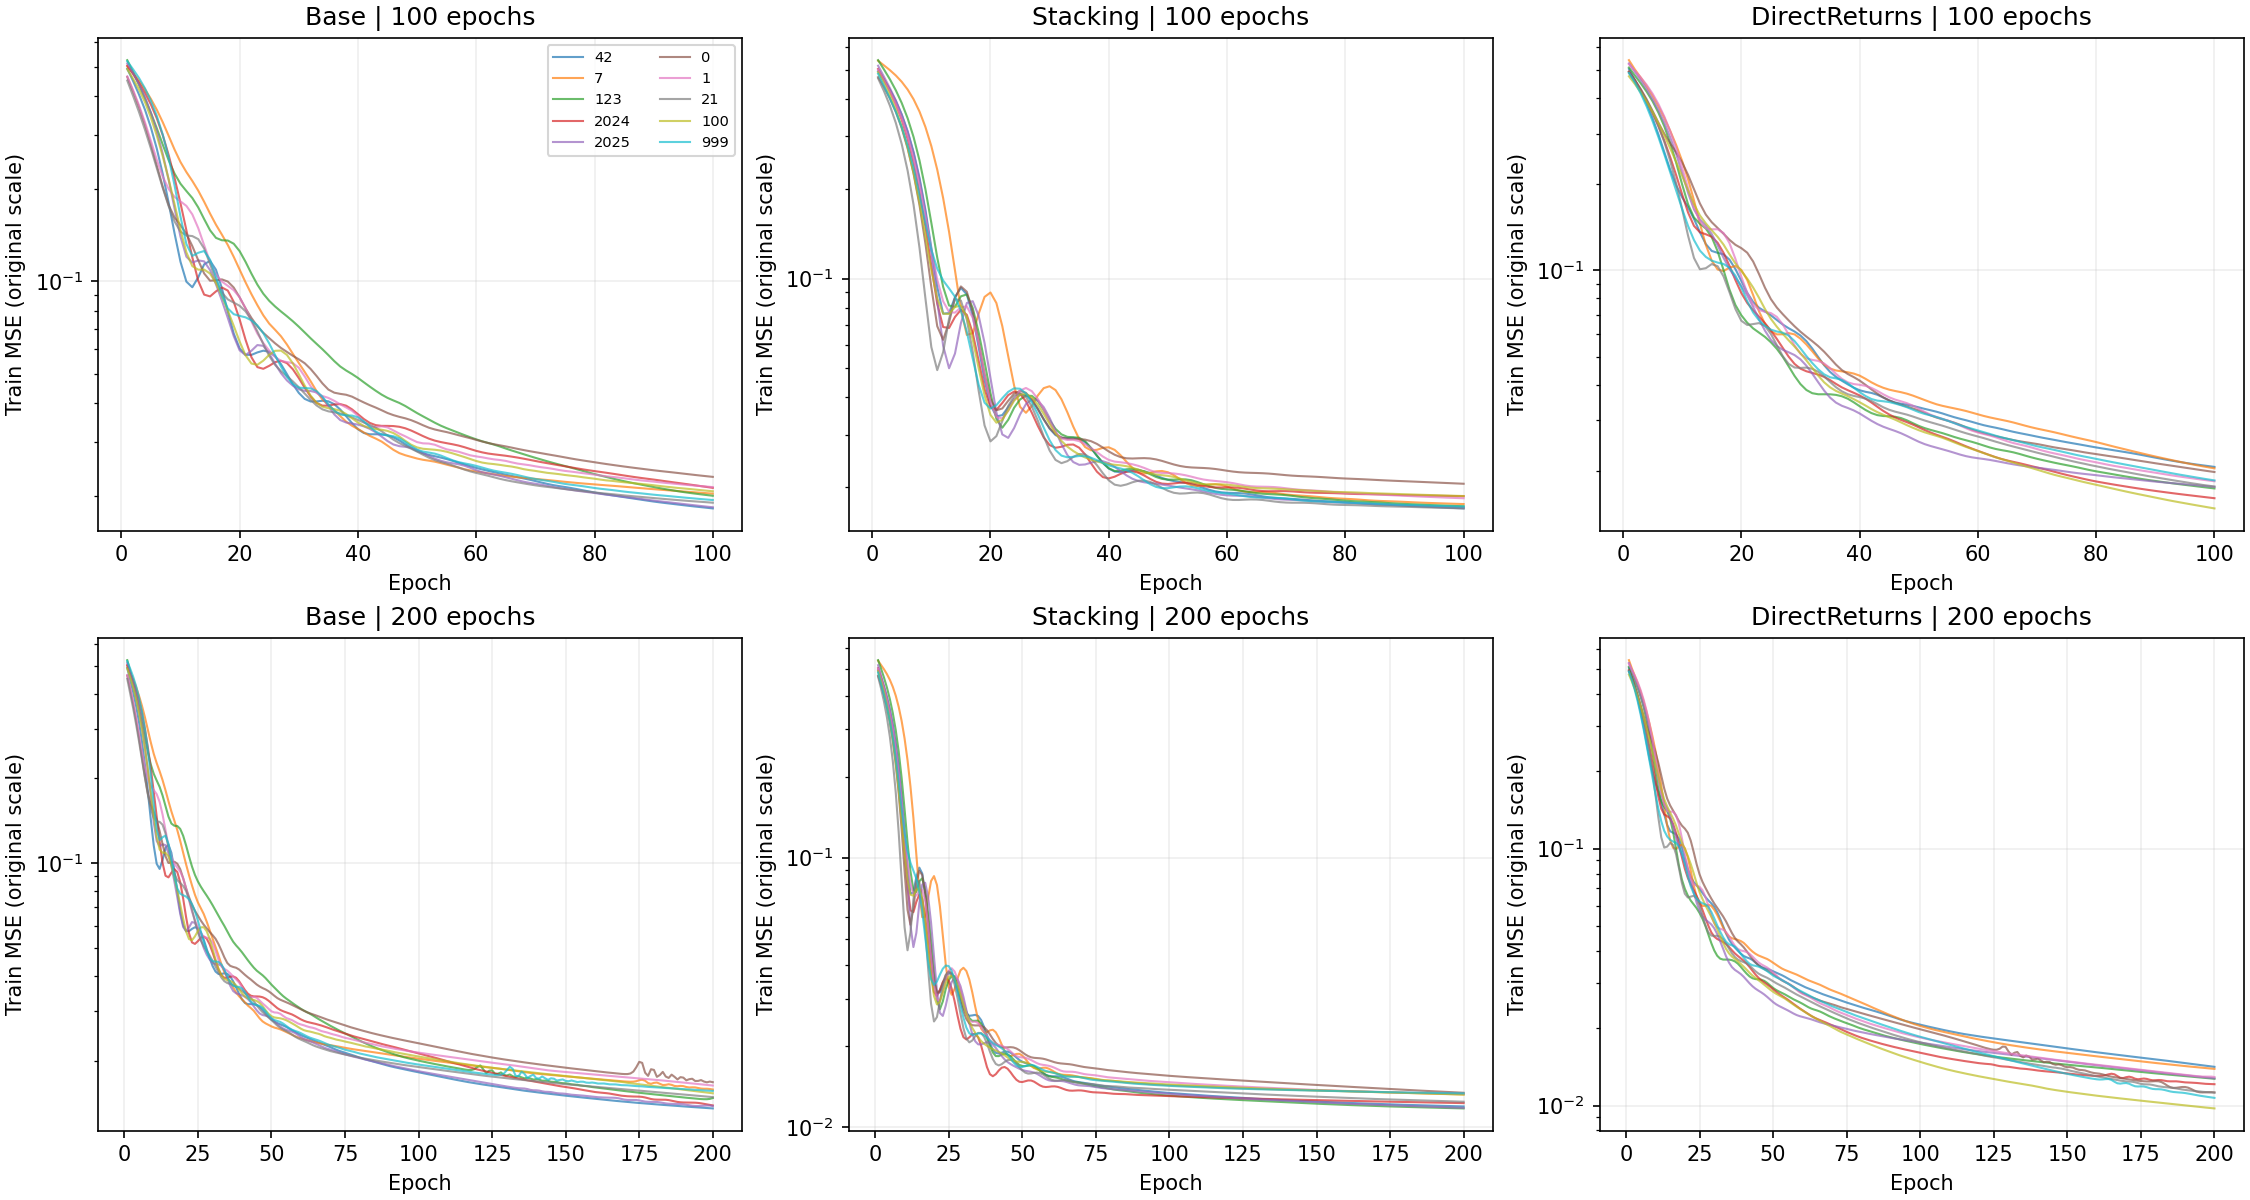

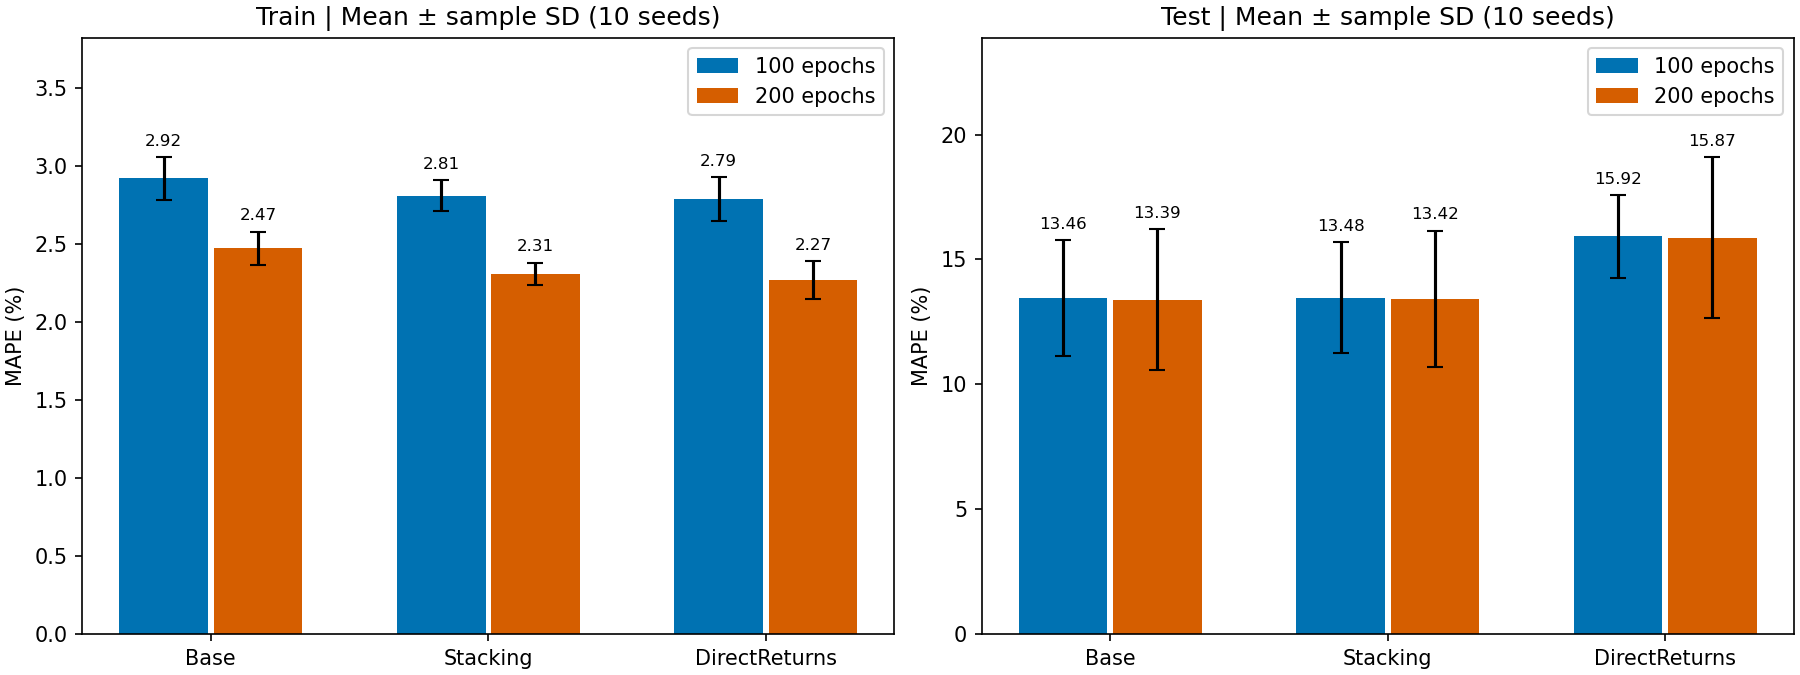

In [4]:
order=['Base','Stacking','DirectReturns']; colors={100:'#0072B2',200:'#D55E00'}
fig,axes=plt.subplots(2,3,figsize=(15,8),constrained_layout=True)
for j,name in enumerate(order):
    for i,budget in enumerate([100,200]):
        ax=axes[i,j]
        for seed in SEEDS:
            g=history10[(history10.Model==name)&(history10.Budget==budget)&(history10.Seed==seed)]
            ax.plot(g.Epoch,g.Train_MSE,lw=1,alpha=.7,label=str(seed))
        ax.set(title=f'{name} | {budget} epochs',xlabel='Epoch',ylabel='Train MSE (original scale)',yscale='log'); ax.grid(alpha=.2)
axes[0,0].legend(ncol=2,fontsize=7)
fig.savefig(OUT/'training_mse_ten_seeds.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'training_mse_ten_seeds.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
for ax,split in zip(axes,['Train','Test']):
    for offset,budget in [(-.17,100),(.17,200)]:
        g=metrics10[(metrics10.Split==split)&(metrics10.Budget==budget)].groupby('Model').MAPE.agg(['mean','std']).reindex(order)
        bars=ax.bar(np.arange(3)+offset,g['mean'],width=.32,yerr=g['std'],capsize=4,color=colors[budget],label=f'{budget} epochs')
        ax.bar_label(bars,fmt='%.2f',padding=4,fontsize=8)
    ax.set(xticks=np.arange(3),xticklabels=order,ylabel='MAPE (%)',title=split+' | Mean ± sample SD (10 seeds)'); ax.legend(); ax.margins(y=.25)
fig.savefig(OUT/'mape_comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'mape_comparison.png')))


---

从20年的实验来看,基准和堆叠的情况下,100轮与200轮相差不大.默认选择100轮.

---

## 十种子实验结论（DirectReturns改为相对滚动均价涨幅）

| 模型 | 每阶段轮数 | 平均训练MSE（原尺度） | 平均训练MAPE | 平均测试MAPE ± 种子样本标准差 |
|---|---:|---:|---:|---:|
|基准|100|0.020134|2.9208%|13.4551% ± 2.3139个百分点|
|基准|200|0.015053|2.4724%|13.3922% ± 2.8091个百分点|
|堆叠|100|0.017912|2.8085%|13.4757% ± 2.2221个百分点|
|堆叠|200|0.012657|2.3071%|13.4174% ± 2.7343个百分点|
|直接加相对滚动均价涨幅|100|0.018124|2.7881%|15.9227% ± 1.6507个百分点|
|直接加相对滚动均价涨幅|200|0.012149|2.2676%|15.8702% ± 3.2299个百分点|

DirectReturns现有4项新增输入：金价/5期均价−1、金价/20期均价−1、铜价/5期均价−1、铜价/20期均价−1。均价包含当前记录；不使用未来数据，不再使用P(t)/P(t−k)−1。堆叠仍比DirectReturns多昨日涨幅指标，因此尚非严格的同特征结构对照。

旧DirectReturns的100/200轮测试均值分别为17.2518%/18.1559%；修改后为15.9227%/15.8702%，有所改善，但仍高于基准。200轮比100轮仅改善0.0525个百分点，种子波动增加。

末段训练诊断：100轮三模型各10组仍下降；200轮Base与DirectReturns各10组仍下降，Stacking有8组仍下降、2组近似平台。不能说全部已收敛。

已核对：前面实验单元保持不变；共同样本日期保持不变；Base与Stacking全部种子和预算的预测保持一致。旧版十种子实验保存在备份笔记本与原结果目录，新结果在 `results/mlp_ten_seeds_ma_11`。2020年仍是反复比较用的测试年，不是独立验证选参结果。


# 2015—2026逐年滚动测试：十种子、100轮、三个模型

每个测试年Y仅使用Y年以前全部有效数据训练，Y年测试，不在测试年内更新模型。种子固定为42、7、123、2024、2025、0、1、21、100、999；每个网络100轮，堆叠两个阶段各100轮，不用折外预测。三个模型使用相同日期，所有标准化仅拟合对应年的训练集。

模型定义沿用上一节：Base原7变量；DirectReturns原7变量加金铜相对5/20期滚动均价涨幅；Stacking为Base预测加金铜昨日涨幅及相对5/20期均价涨幅。均价包含当日，按原始记录窗口计算，目标为同日股价。共同剔除最初20条记录，保持2020年的实验可复现。

报告每年10种子平均MAPE及样本标准差，年度等权平均与按测试样本数加权平均分别列示。2026仅数据已有日期，不完整年份单列，同时报告2015—2025完整年份汇总。

“突变”仅作描述性检查：列出相邻年份平均MAPE变化，绝对变化≥5个百分点标记为明显年度跳变，另外列出相邻年份变化最大的项目。这不是统计变点检验，也不是经济因果判断。不用这些测试结果进行早停或筛选种子。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_ANNUAL_MA_OUT', str(ROOT/'results/mlp_annual_ten_ma_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123,2024,2025,0,1,21,100,999]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2026]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
DIRECT=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_ma_deviation{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        DIRECT.append(name)
FULL=BASE+DIRECT
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
valid = valid & (x.index >= raw.index[20])
x=x.loc[valid]; y=y.loc[x.index]
assert len(x.index[x.index.year<2020])==2034
for metal in ['gold','copper']:
    for k in [5,20]:
        assert np.allclose(x[f'{metal}_ma_deviation{k}'], x[f'{metal}_vs_ma{k}'])
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
# 此处2020切分仅为初始化；实际按下面逐年循环保存全部切分。
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
config['direct_features']=FULL
config['epoch_budgets_per_stage']=[100]
config['test_years']=list(range(2015,2027))
config.pop('test_year',None)
config['split']='expanding train before test year; no OOF'
config['jump_threshold_pp']=5
config.pop('epochs_per_stage',None)
config['direct_return_formula']='P(t)/MA_k(t)-1; k=5,20; trailing mean includes current record'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def fit3(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel()
        mse=float(np.mean((p-np.asarray(Y))**2))
        H.append(dict(Year=YEAR,Seed=seed,Budget=EPOCHS,Model=label,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    return model,sx,sy

def pred3(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

rows=[]; frames=[]; splitrows=[]
EPOCHS=100
for YEAR in range(2015,2027):
    tr=x.index[x.index.year<YEAR]; te=x.index[x.index.year==YEAR]
    assert len(tr)>0 and len(te)>0 and tr.max()<te.min()
    for split,idx in [('Train',tr),('Test',te)]:
        splitrows.append(dict(Year=YEAR,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    for seed in SEEDS:
        current=x.loc[x.index.year<=YEAR]
        base=fit3(x.loc[tr,BASE],y.loc[tr],seed,'Base')
        bp=pred3(base,current[BASE])
        meta=current[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
        stack=fit3(meta.loc[tr],y.loc[tr],seed,'Stacking')
        direct=fit3(x.loc[tr,FULL],y.loc[tr],seed,'DirectReturns')
        for name,bundle,X in [('Base',base,current[BASE]),('Stacking',stack,meta),('DirectReturns',direct,current[FULL])]:
            pred=pred3(bundle,X); model,sx,sy=bundle
            torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,
                sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{YEAR}_{name}_{EPOCHS}_seed{seed}.pt')
            for split,idx in [('Train',tr),('Test',te)]:
                a=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy(); mse=np.mean((p-a)**2)
                rows.append(dict(Year=YEAR,Seed=seed,Budget=EPOCHS,Model=name,Split=split,N=len(idx),MAPE=100*np.mean(np.abs(p-a)/np.abs(a)),MSE=mse,MSE_standardized=mse/float(sy.scale_[0]**2)))
                frames.append(pd.DataFrame(dict(Date=idx,Year=YEAR,Seed=seed,Budget=EPOCHS,Model=name,Split=split,Actual=a,Predicted=p)))
        if seed==SEEDS[-1]: print(f'{YEAR}: ten seeds / three models completed',flush=True)


2015: ten seeds / three models completed
2016: ten seeds / three models completed
2017: ten seeds / three models completed
2018: ten seeds / three models completed
2019: ten seeds / three models completed
2020: ten seeds / three models completed
2021: ten seeds / three models completed
2022: ten seeds / three models completed
2023: ten seeds / three models completed
2024: ten seeds / three models completed
2025: ten seeds / three models completed
2026: ten seeds / three models completed


In [3]:
annual_metrics=pd.DataFrame(rows); annual_history=pd.DataFrame(H); annual_predictions=pd.concat(frames,ignore_index=True)
assert len(annual_metrics)==720 and len(annual_history)==36000
assert np.isfinite(annual_metrics[['MAPE','MSE']]).all().all()
annual_metrics.to_csv(OUT/'metrics.csv',index=False); annual_history.to_csv(OUT/'training_history.csv',index=False)
annual_predictions.to_csv(OUT/'predictions.csv',index=False); pd.DataFrame(splitrows).to_csv(OUT/'splits.csv',index=False)
order=['Base','Stacking','DirectReturns']
test=annual_metrics[annual_metrics.Split=='Test']
annual_mean=test.groupby(['Year','Model']).MAPE.mean().unstack().reindex(columns=order)
annual_std=test.groupby(['Year','Model']).MAPE.std().unstack().reindex(columns=order)
train_mean=annual_metrics[annual_metrics.Split=='Train'].groupby(['Year','Model']).MAPE.mean().unstack().reindex(columns=order)
mse_mean=annual_metrics[annual_metrics.Split=='Train'].groupby(['Year','Model']).MSE.mean().unstack().reindex(columns=order)
for name,table in [('annual_test_mean',annual_mean),('annual_test_std',annual_std),('annual_train_mean',train_mean),('annual_train_mse',mse_mean)]:table.to_csv(OUT/f'{name}.csv')
yoy=annual_mean.diff(); yoy.to_csv(OUT/'year_over_year_change_pp.csv')
jumps=yoy.stack().rename('Change_pp').reset_index(); jumps['Abs_change_pp']=jumps.Change_pp.abs(); jumps['Flag_ge_5pp']=jumps.Abs_change_pp>=5
jumps=jumps.sort_values('Abs_change_pp',ascending=False); jumps.to_csv(OUT/'annual_jumps.csv',index=False)
summaryrows=[]
for period,selection in [('2015-2025',test[test.Year<=2025]),('2015-2026_partial',test)]:
    for model,g in selection.groupby('Model'):
        seedmean=g.groupby('Seed').MAPE.mean()
        summaryrows.append(dict(Period=period,Model=model,Annual_equal_mean_MAPE=seedmean.mean(),Across_seed_SD=seedmean.std(),Sample_weighted_MAPE=np.average(g.MAPE,weights=g.N)))
annual_summary=pd.DataFrame(summaryrows); annual_summary.to_csv(OUT/'summary.csv',index=False)
paired=test.pivot(index=['Year','Seed'],columns='Model',values='MAPE')
paired['Stacking_minus_Base']=paired.Stacking-paired.Base
paired['DirectReturns_minus_Base']=paired.DirectReturns-paired.Base
paired.to_csv(OUT/'paired_seed_differences.csv')
relative=paired.groupby('Year')[['Stacking_minus_Base','DirectReturns_minus_Base']].mean()
relative.to_csv(OUT/'annual_difference_vs_base.csv')
winrows=[]
for year,g in paired.groupby('Year'):
    winrows.append(dict(Year=year,Stacking_seeds_better=int((g.Stacking_minus_Base<0).sum()),DirectReturns_seeds_better=int((g.DirectReturns_minus_Base<0).sum())))
wins=pd.DataFrame(winrows); wins.to_csv(OUT/'annual_seed_wins.csv',index=False)
# 复核2020年100轮全种子全模型预测与上节一致。
prior=OUT.parent/'mlp_ten_seeds_ma_11/predictions.csv'
if prior.exists():
    old=pd.read_csv(prior,parse_dates=['Date']); old=old[old.Budget==100]
    new=annual_predictions[annual_predictions.Year==2020]
    check=old.merge(new,on=['Date','Seed','Model','Split','Budget'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==len(old)==len(new)
    assert np.allclose(check.Predicted_old,check.Predicted_new,rtol=0,atol=1e-6)
    print('复核通过：2020年100轮、十种子、三模型预测与上节一致。')
print('年度测试MAPE均值：'); display(annual_mean.round(3))
print('年度种子标准差：'); display(annual_std.round(3))
print('跨年度汇总：'); display(annual_summary.round(4))
print('年度跳变（>=5个百分点）：'); display(jumps[jumps.Flag_ge_5pp].round(3))
print('相对基准平均差、逐年改善种子数：'); display(relative.round(3)); display(wins)


Model,Base,Stacking,DirectReturns
Year,,,
2015,8.096,8.990,10.767
2016,8.283,8.551,7.229
2017,13.212,13.644,13.025
2018,7.517,7.704,7.432
2019,10.490,10.524,8.391
2020,13.455,13.476,15.923
2021,8.545,9.572,8.046
2022,31.856,31.799,30.425
2023,13.115,13.793,12.488


Model,Base,Stacking,DirectReturns
Year,,,
2015,3.199,2.953,2.177
2016,3.036,3.024,2.704
2017,1.606,1.764,1.897
2018,2.057,2.254,1.240
2019,3.131,3.218,2.181
2020,2.314,2.222,1.651
2021,3.856,4.452,2.745
2022,8.141,8.243,5.214
2023,3.286,2.828,2.511


,Period,Model,Annual_equal_mean_MAPE,Across_seed_SD,Sample_weighted_MAPE
0,2015-2025,Base,12.6631,1.0788,12.6895
1,2015-2025,DirectReturns,12.6454,0.7574,12.6655
2,2015-2025,Stacking,13.1367,1.1604,13.1642
3,2015-2026_partial,Base,12.4310,0.9913,12.5527
4,2015-2026_partial,DirectReturns,12.2659,0.7088,12.4430
5,2015-2026_partial,Stacking,12.7872,1.0277,12.9589


,Year,Model,Change_pp,Abs_change_pp,Flag_ge_5pp
18,2022,Base,23.311,23.311,True
20,2022,DirectReturns,22.379,22.379,True
19,2022,Stacking,22.227,22.227,True
21,2023,Base,-18.741,18.741,True
22,2023,Stacking,-18.006,18.006,True
23,2023,DirectReturns,-17.936,17.936,True
29,2025,DirectReturns,9.215,9.215,True
32,2026,DirectReturns,-9.203,9.203,True
27,2025,Base,8.147,8.147,True
17,2021,DirectReturns,-7.876,7.876,True


Model,Stacking_minus_Base,DirectReturns_minus_Base
Year,,
2015,0.893,2.671
2016,0.268,-1.055
2017,0.432,-0.187
2018,0.187,-0.086
2019,0.034,-2.099
2020,0.021,2.468
2021,1.026,-0.499
2022,-0.057,-1.431
2023,0.678,-0.627


,Year,Stacking_seeds_better,DirectReturns_seeds_better
0,2015,0,3
1,2016,0,5
2,2017,0,4
3,2018,2,4
4,2019,3,7
5,2020,4,3
6,2021,2,4
7,2022,5,6
8,2023,1,4
9,2024,0,5


复核通过：2020年100轮、十种子、三模型预测与上节一致。
年度测试MAPE均值：
年度种子标准差：
跨年度汇总：
年度跳变（>=5个百分点）：
相对基准平均差、逐年改善种子数：


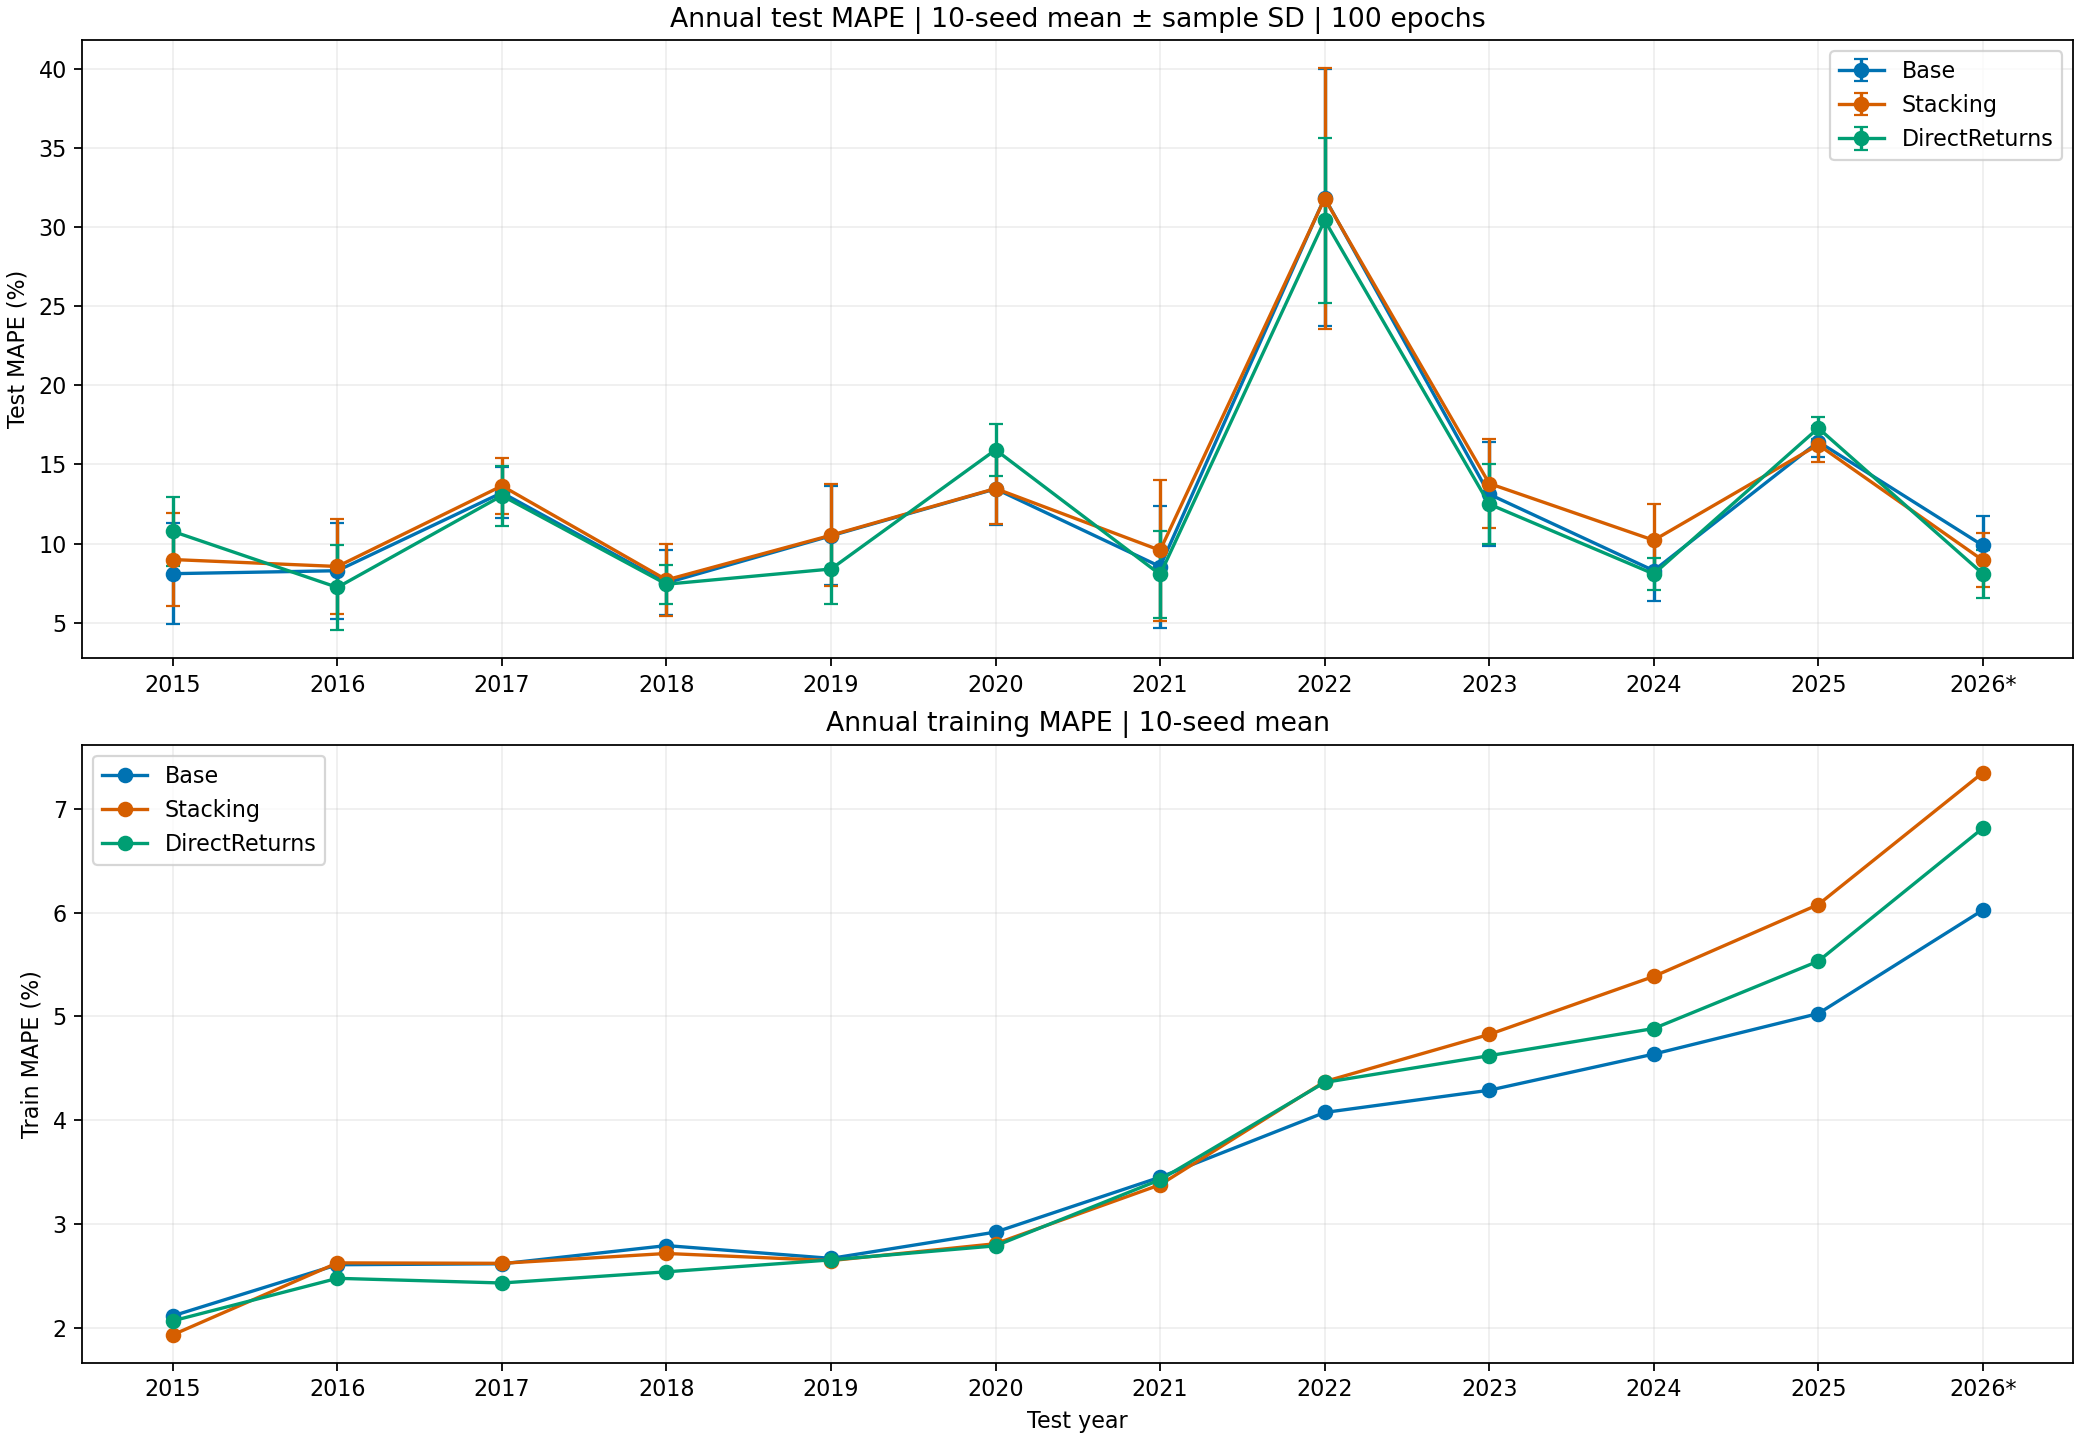

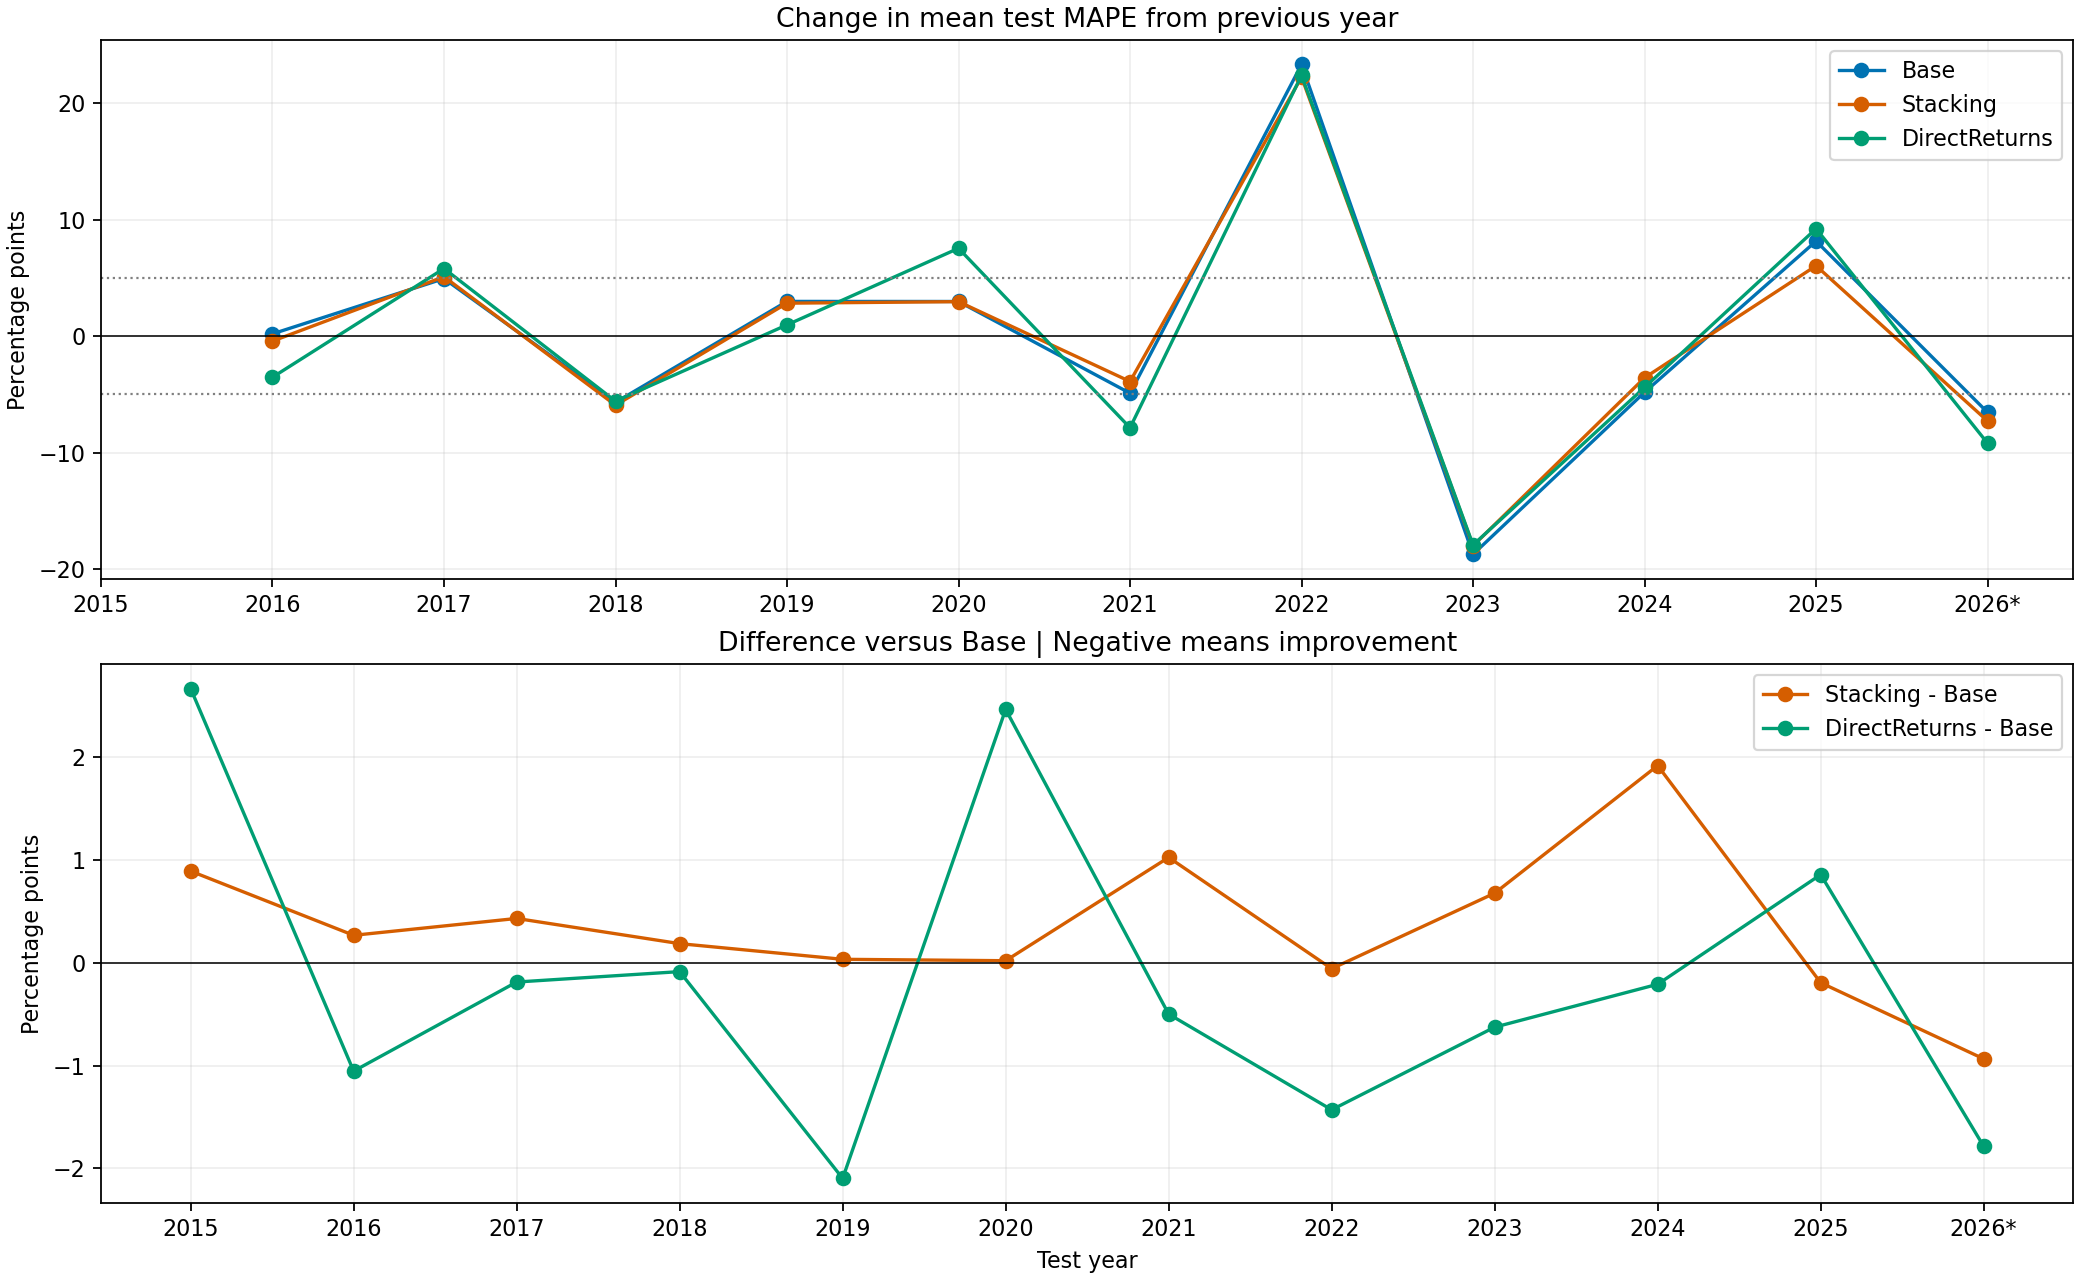

* 2026 is partial; see splits.csv for exact data end date.


In [4]:
colors={'Base':'#0072B2','Stacking':'#D55E00','DirectReturns':'#009E73'}
fig,axes=plt.subplots(2,1,figsize=(13,9),constrained_layout=True)
for model in order:
    axes[0].errorbar(annual_mean.index,annual_mean[model],yerr=annual_std[model],marker='o',capsize=3,color=colors[model],label=model)
    axes[1].plot(train_mean.index,train_mean[model],marker='o',color=colors[model],label=model)
axes[0].set(title='Annual test MAPE | 10-seed mean ± sample SD | 100 epochs',ylabel='Test MAPE (%)')
axes[1].set(title='Annual training MAPE | 10-seed mean',ylabel='Train MAPE (%)',xlabel='Test year')
for ax in axes:
    ax.set_xticks(annual_mean.index); ax.set_xticklabels([str(y) if y!=2026 else '2026*' for y in annual_mean.index]); ax.grid(alpha=.2); ax.legend()
fig.savefig(OUT/'annual_mape.png',dpi=160); plt.close(fig); display(Image(filename=str(OUT/'annual_mape.png')))
fig,axes=plt.subplots(2,1,figsize=(13,8),constrained_layout=True)
for model in order:
    axes[0].plot(yoy.index,yoy[model],marker='o',color=colors[model],label=model)
for model in ['Stacking','DirectReturns']:
    axes[1].plot(annual_mean.index,annual_mean[model]-annual_mean.Base,marker='o',color=colors[model],label=model+' - Base')
axes[0].set(title='Change in mean test MAPE from previous year',ylabel='Percentage points'); axes[0].axhline(5,color='gray',ls=':',lw=1); axes[0].axhline(-5,color='gray',ls=':',lw=1)
axes[1].set(title='Difference versus Base | Negative means improvement',ylabel='Percentage points',xlabel='Test year')
for ax in axes:
    ax.axhline(0,color='black',lw=.7); ax.set_xticks(annual_mean.index); ax.set_xticklabels([str(y) if y!=2026 else '2026*' for y in annual_mean.index]); ax.grid(alpha=.2); ax.legend()
fig.savefig(OUT/'annual_changes.png',dpi=160); plt.close(fig); display(Image(filename=str(OUT/'annual_changes.png')))
print('* 2026 is partial; see splits.csv for exact data end date.')


## 逐年实验结论

| 年份 | Base | Stacking | DirectReturns（相对滚动均价） |
|---|---:|---:|---:|
|2015|8.096%|8.990%|10.767%|
|2016|8.283%|8.551%|7.229%|
|2017|13.212%|13.644%|13.025%|
|2018|7.517%|7.704%|7.432%|
|2019|10.490%|10.524%|8.391%|
|2020|13.455%|13.476%|15.923%|
|2021|8.545%|9.572%|8.046%|
|2022|31.856%|31.799%|30.425%|
|2023|13.115%|13.793%|12.488%|
|2024|8.288%|10.209%|8.079%|
|2025|16.436%|16.242%|17.295%|
|2026（部分）|9.878%|8.943%|8.092%|

**完整年份2015—2025年度等权平均**：Base 12.6631%，Stacking 13.1367%，DirectReturns 12.6454%。DirectReturns较Base仅低0.0177个百分点，基本持平；Stacking平均高0.4736个百分点。

**含2026部分年份的年度等权平均**：Base 12.4310%，Stacking 12.7872%，DirectReturns 12.2659%。2026仅覆盖2026-01-01至2026-07-23，共152条记录；将它与完整年份等权会改变比较权重，应优先同时看完整年份汇总。

明显变化：

- **2022年为最大共同误差峰值**。三个模型均值30.42%—31.86%，比2021年上升22.23—23.31个百分点；种子标准差分别为Base 8.14、Stacking 8.24、DirectReturns 5.21个百分点，也高于其他年份。提示共同的跨期泛化困难，不能仅据此认定市场结构突变，具体原因仍需分析输入分布和误差方向。
- **2023年显著回落**，较2022年下降17.94—18.74个百分点。
- **2025年再度上升**，较2024年增加约6.03—9.22个百分点；2026均值下降，但因期间不完整，不宜直接视为全年恢复。
- DirectReturns在12个测试年中的9年均值低于Base，但2015、2020、2025年更差；较多年份小幅改善被少数年份恶化抵消，因此完整年份整体均值接近。
- Stacking只有2022、2025、2026年的均值低于Base，整体未见稳定优势。2026年10/10个种子均改善，但不能单凭该年推广。

训练MAPE在后期训练窗口逐渐上升。各年训练样本、目标尺度和市场覆盖不同，不能把这种跨年变化直接解释为数值不收敛；训练使用MSE，与MAPE目标也不同。

本实验没有验证集；年度跳变是描述性现象，非正式变点检验或显著性结论。DirectReturns仍比Stacking少两项昨日涨幅，结构对比尚非严格同特征对照。

已复核2020年十个种子、三个模型的预测与前一节完全一致（容许1e-6浮点误差）。结果、模型、逐日预测、年度均值/标准差、配对差和图表保存在 `results/mlp_annual_ten_ma_11`。


---

从这次实验数据来看,取了10个种子,偶然的可能性较小.平均来看,仍然是把金属价格对滚动均价的偏离放在第一层模型效果更好.采用了堆叠的模式,效果比基准模型还要差.

我们再比较一下原来的与5日与20日前的涨跌幅做对比.

---

# DirectReturns两种定义：2015—2026年、十种子、100轮

只比较两个单阶段模型，均为原7项输入加金铜4项变化指标，总输入维度11，隐藏层16→32、ReLU、Adam学习率0.01、全批量、每个模型100轮。

- **DirectMA**：金/铜各自 `P(t)/MA5(t)−1`、`P(t)/MA20(t)−1`；均价包含当日。
- **DirectLag**：金/铜各自 `P(t)/P(t−5)−1`、`P(t)/P(t−20)−1`；与之前06的定义一致。

5/20均按原数据相邻记录计数。特征顺序均为原7项、金5、金20、铜5、铜20；同一个种子在两组中使用相同的初始网络权重，以配对比较特征定义。种子固定42、7、123、2024、2025、0、1、21、100、999。

每个测试年仅使用此前历史训练，各年两模型的训练/测试日期完全一致；标准化器只拟合当年训练集，目标仍为同日股价。沿用共同剔除最初20条记录的口径。2026为部分年份，不设验证集，不根据测试误差选择种子或训练轮数。

按年报告十种子平均MAPE、样本标准差及配对差（DirectLag减DirectMA，负数表示滞后变化率更好）。总体同时报告2015—2025完整年份与含2026部分年份的年度等权平均、样本数加权平均。保留全部训练MSE与训练MAPE。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_DEFINITION_OUT', str(ROOT/'results/mlp_direct_definition_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123,2024,2025,0,1,21,100,999]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2026]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
DIRECT=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_ma_deviation{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        DIRECT.append(name)
LAG=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_lag_return{k}'
        x[name]=raw[col]/raw[col].shift(k)-1
        LAG.append(name)
FULL=BASE+DIRECT
GROUPS={'DirectMA':FULL,'DirectLag':BASE+LAG}
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
valid = valid & (x.index >= raw.index[20])
x=x.loc[valid]; y=y.loc[x.index]
assert len(x.index[x.index.year<2020])==2034
for metal in ['gold','copper']:
    for k in [5,20]:
        assert np.allclose(x[f'{metal}_ma_deviation{k}'], x[f'{metal}_vs_ma{k}'])
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
# 此处2020切分仅为初始化；实际按下面逐年循环保存全部切分。
display(pd.DataFrame(GROUPS))


,DirectMA,DirectLag
0,A_500,A_500
1,Dollar Index,Dollar Index
2,cn_10y_rate,cn_10y_rate
3,us_10y_rate,us_10y_rate
4,brent,brent
5,Copper Futures Price,Copper Futures Price
6,Gold Futures Price,Gold Futures Price
7,gold_ma_deviation5,gold_lag_return5
8,gold_ma_deviation20,gold_lag_return20
9,copper_ma_deviation5,copper_lag_return5


In [2]:
config.pop('test_year',None); config.pop('stage2_features',None); config.pop('stage2_training',None)
config.update(test_years=list(range(2015,2027)),epochs=100,groups=GROUPS,
    definitions={'DirectMA':'P(t)/MA_k(t)-1; includes current record','DirectLag':'P(t)/P(t-k)-1'},
    windows=[5,20],split='expanding train before test year',paired_initialization=True)
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def fit3(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel()
        mse=float(np.mean((p-np.asarray(Y))**2))
        H.append(dict(Year=YEAR,Seed=seed,Budget=EPOCHS,Model=label,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    return model,sx,sy

def pred3(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

rows=[]; frames=[]; splitrows=[]
EPOCHS=100
for YEAR in range(2015,2027):
    tr=x.index[x.index.year<YEAR]; te=x.index[x.index.year==YEAR]
    assert len(tr)>0 and len(te)>0 and tr.max()<te.min()
    for split,idx in [('Train',tr),('Test',te)]:
        splitrows.append(dict(Year=YEAR,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    current=x.loc[x.index.year<=YEAR]
    for seed in SEEDS:
        for name,cols in GROUPS.items():
            bundle=fit3(x.loc[tr,cols],y.loc[tr],seed,name)
            pred=pred3(bundle,current[cols]); model,sx,sy=bundle
            torch.save(dict(state_dict=model.state_dict(),features=cols,seed=seed,epochs=EPOCHS,year=YEAR,
                sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{YEAR}_{name}_seed{seed}.pt')
            for split,idx in [('Train',tr),('Test',te)]:
                a=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy(); mse=np.mean((p-a)**2)
                rows.append(dict(Year=YEAR,Seed=seed,Budget=EPOCHS,Model=name,Split=split,N=len(idx),MAPE=100*np.mean(np.abs(p-a)/np.abs(a)),MSE=mse,MSE_standardized=mse/float(sy.scale_[0]**2)))
                frames.append(pd.DataFrame(dict(Date=idx,Year=YEAR,Seed=seed,Budget=EPOCHS,Model=name,Split=split,Actual=a,Predicted=p)))
    print(f'{YEAR}: ten seeds / both definitions completed',flush=True)


2015: ten seeds / both definitions completed
2016: ten seeds / both definitions completed
2017: ten seeds / both definitions completed
2018: ten seeds / both definitions completed
2019: ten seeds / both definitions completed
2020: ten seeds / both definitions completed
2021: ten seeds / both definitions completed
2022: ten seeds / both definitions completed
2023: ten seeds / both definitions completed
2024: ten seeds / both definitions completed
2025: ten seeds / both definitions completed
2026: ten seeds / both definitions completed


In [3]:
metrics_def=pd.DataFrame(rows); history_def=pd.DataFrame(H); predictions_def=pd.concat(frames,ignore_index=True)
assert len(metrics_def)==480 and len(history_def)==24000
assert np.isfinite(metrics_def[['MSE','MAPE']]).all().all()
metrics_def.to_csv(OUT/'metrics.csv',index=False); history_def.to_csv(OUT/'training_history.csv',index=False)
predictions_def.to_csv(OUT/'predictions.csv',index=False); pd.DataFrame(splitrows).to_csv(OUT/'splits.csv',index=False)
order=['DirectMA','DirectLag']
test=metrics_def[metrics_def.Split=='Test']
annual_mean=test.groupby(['Year','Model']).MAPE.mean().unstack().reindex(columns=order)
annual_std=test.groupby(['Year','Model']).MAPE.std().unstack().reindex(columns=order)
annual_train=metrics_def[metrics_def.Split=='Train'].groupby(['Year','Model'])[['MAPE','MSE']].mean()
annual_mean.to_csv(OUT/'annual_test_mean.csv'); annual_std.to_csv(OUT/'annual_test_std.csv'); annual_train.to_csv(OUT/'annual_train.csv')
paired=test.pivot(index=['Year','Seed'],columns='Model',values='MAPE')
paired['Lag_minus_MA_pp']=paired.DirectLag-paired.DirectMA
paired.to_csv(OUT/'paired_differences.csv')
paired_summary=paired.groupby('Year').Lag_minus_MA_pp.agg(['mean','std','min','max'])
paired_summary['Lag_better_seeds']=paired.Lag_minus_MA_pp.lt(0).groupby('Year').sum()
paired_summary.to_csv(OUT/'annual_paired_summary.csv')
summaryrows=[]
for period,selection in [('2015-2025',test[test.Year<=2025]),('2015-2026_partial',test)]:
    for model,g in selection.groupby('Model'):
        seedmean=g.groupby('Seed').MAPE.mean()
        summaryrows.append(dict(Period=period,Model=model,Annual_equal_mean_MAPE=seedmean.mean(),Across_seed_SD=seedmean.std(),Sample_weighted_MAPE=np.average(g.MAPE,weights=g.N)))
summary_def=pd.DataFrame(summaryrows); summary_def.to_csv(OUT/'summary.csv',index=False)
annual_mean.diff().to_csv(OUT/'year_over_year_change_pp.csv')
# 相对均价模型应复现上一节所有年度与种子的逐日预测。
prior=OUT.parent/'mlp_annual_ten_ma_11/predictions.csv'
if prior.exists():
    old=pd.read_csv(prior,parse_dates=['Date']); old=old[old.Model=='DirectReturns'].copy(); old['Model']='DirectMA'
    new=predictions_def[predictions_def.Model=='DirectMA']
    check=old.merge(new,on=['Date','Year','Seed','Model','Split','Budget'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==len(old)==len(new)
    assert np.array_equal(check.Predicted_old.to_numpy(dtype=np.float32),check.Predicted_new.to_numpy(dtype=np.float32))
    print('复核通过：DirectMA在全部12年、十种子的预测均与上一节一致。')
# 原2020十种子滞后变化率也应复现（100轮）。
prior_lag=OUT.parent/'mlp_ten_seeds_11/metrics.csv'
if prior_lag.exists():
    old=pd.read_csv(prior_lag); old=old[(old.Model=='DirectReturns')&(old.Budget==100)]
    new=metrics_def[(metrics_def.Year==2020)&(metrics_def.Model=='DirectLag')]
    check=old.merge(new,on=['Seed','Split'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==20 and np.allclose(check.MAPE_old,check.MAPE_new,rtol=0,atol=1e-6)
    print('复核通过：DirectLag的2020年100轮结果复现此前十种子实验。')
print('年度平均MAPE：'); display(annual_mean.round(4))
print('年度种子标准差：'); display(annual_std.round(4))
print('配对差（滞后−均价）及改善种子数：'); display(paired_summary.round(4))
print('总体汇总：'); display(summary_def.round(4))


Model,DirectMA,DirectLag
Year,,
2015,10.7671,10.8177
2016,7.2286,6.1065
2017,13.0250,12.3578
2018,7.4316,7.5356
2019,8.3907,8.5623
2020,15.9227,17.2518
2021,8.0462,7.4651
2022,30.4248,31.2412
2023,12.4883,13.2793


Model,DirectMA,DirectLag
Year,,
2015,2.1771,1.8065
2016,2.7040,2.1612
2017,1.8965,1.6641
2018,1.2395,1.2811
2019,2.1807,2.2084
2020,1.6507,2.9038
2021,2.7452,1.6894
2022,5.2145,5.7753
2023,2.5107,2.4048


,mean,std,min,max,Lag_better_seeds
Year,,,,,
2015,0.0506,1.5944,-1.4767,3.5433,5
2016,-1.1221,1.1506,-3.1575,0.5594,8
2017,-0.6673,0.8347,-2.5497,0.5015,8
2018,0.1039,0.8336,-0.8511,1.4257,7
2019,0.1717,1.0588,-1.8128,1.9689,4
2020,1.3291,2.1476,-2.7922,4.7036,3
2021,-0.5811,1.6302,-4.9080,0.8199,7
2022,0.8164,1.2734,-0.6911,3.4029,3
2023,0.7909,0.9126,-0.2738,2.2585,2


,Period,Model,Annual_equal_mean_MAPE,Across_seed_SD,Sample_weighted_MAPE
0,2015-2025,DirectLag,12.7300,0.9072,12.7534
1,2015-2025,DirectMA,12.6454,0.7574,12.6655
2,2015-2026_partial,DirectLag,12.2898,0.8439,12.4953
3,2015-2026_partial,DirectMA,12.2659,0.7088,12.4430


复核通过：DirectMA在全部12年、十种子的预测均与上一节一致。
复核通过：DirectLag的2020年100轮结果复现此前十种子实验。
年度平均MAPE：
年度种子标准差：
配对差（滞后−均价）及改善种子数：
总体汇总：


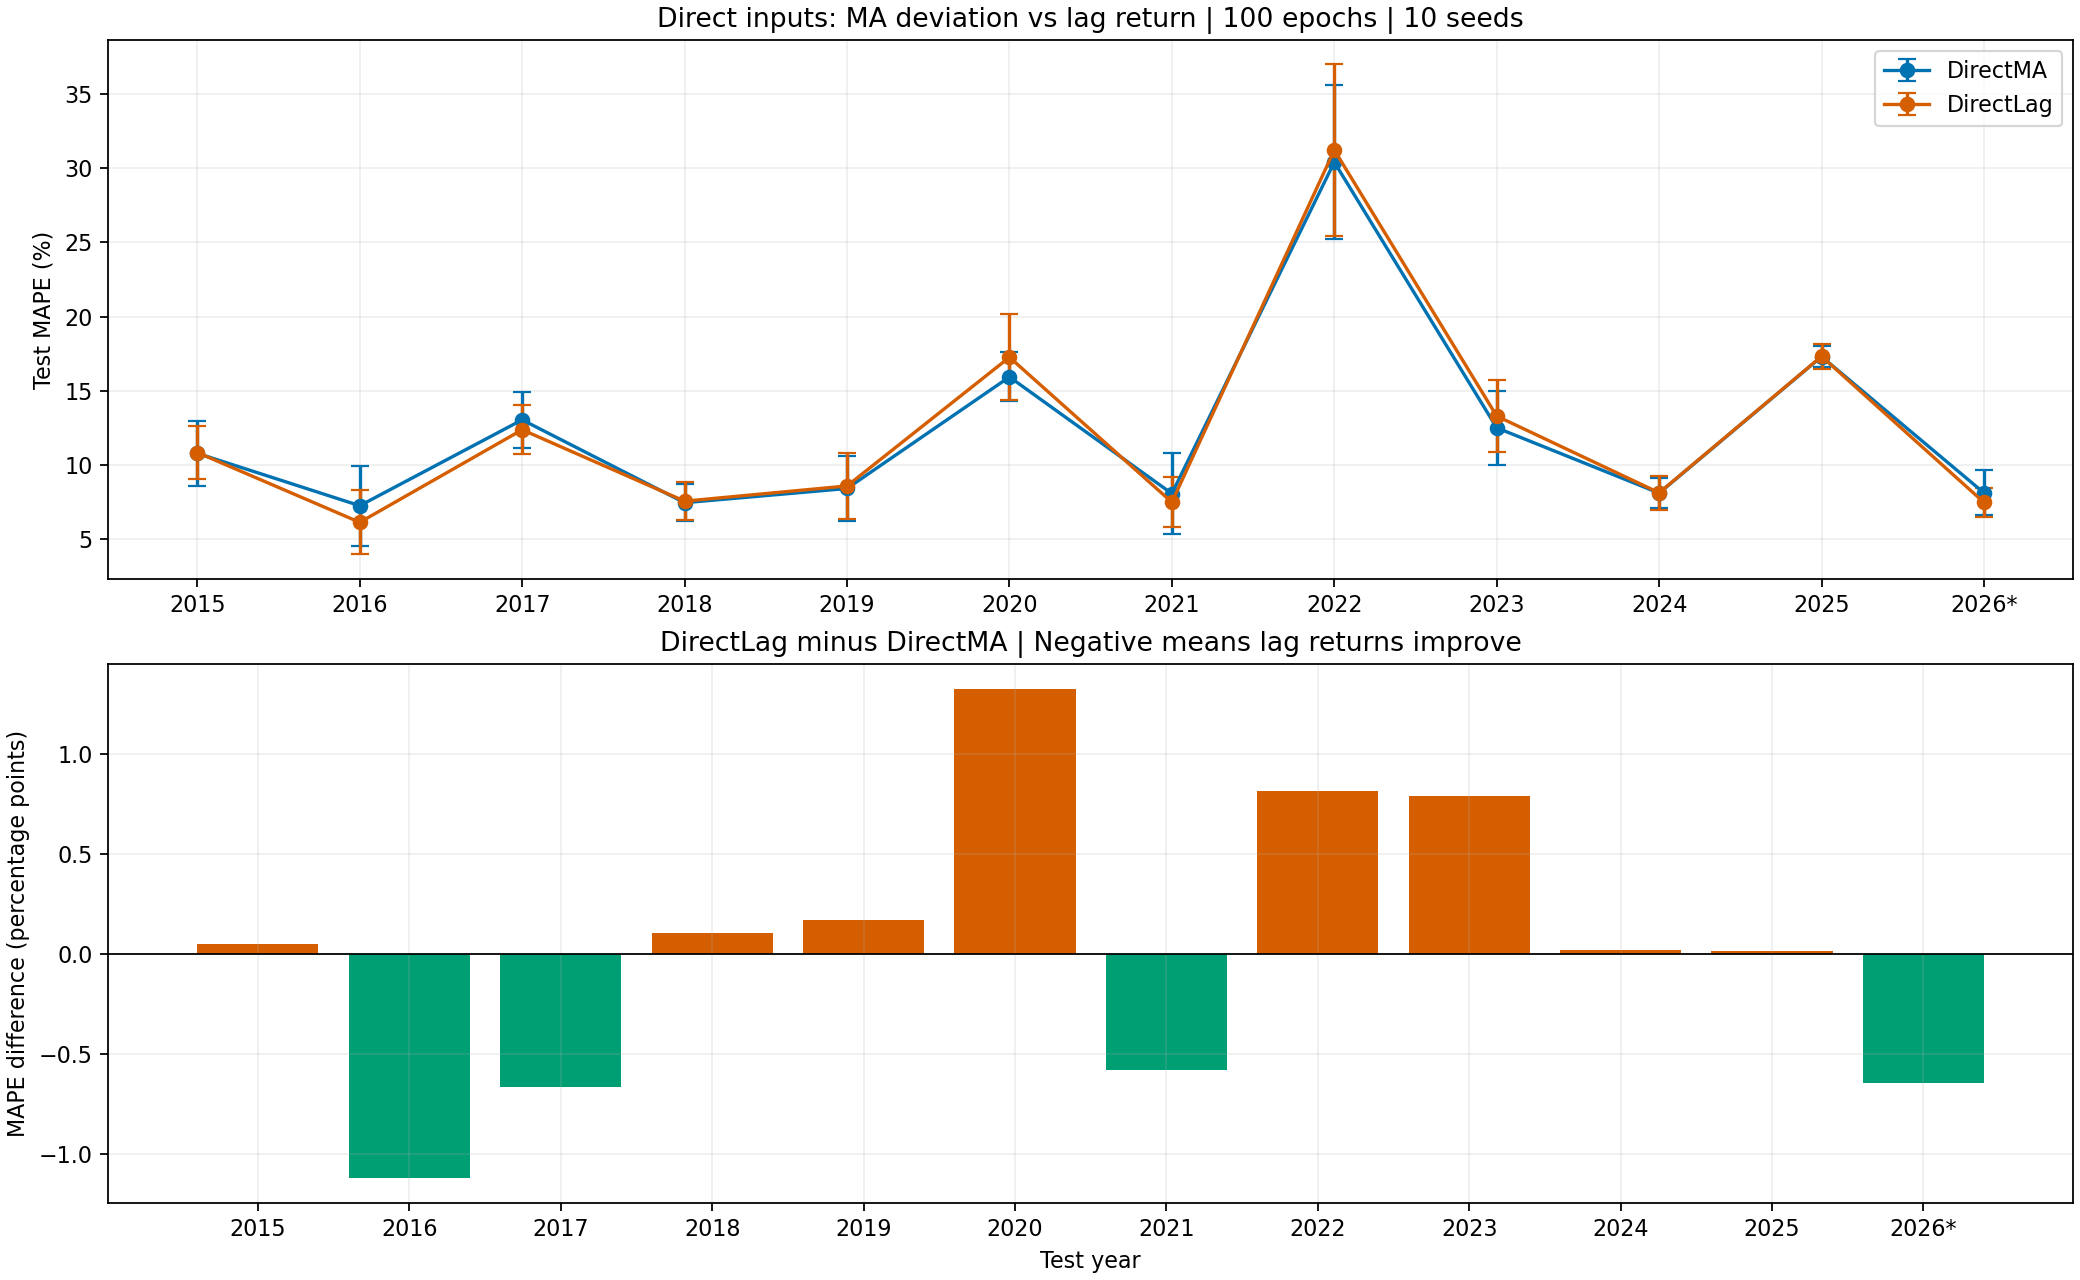

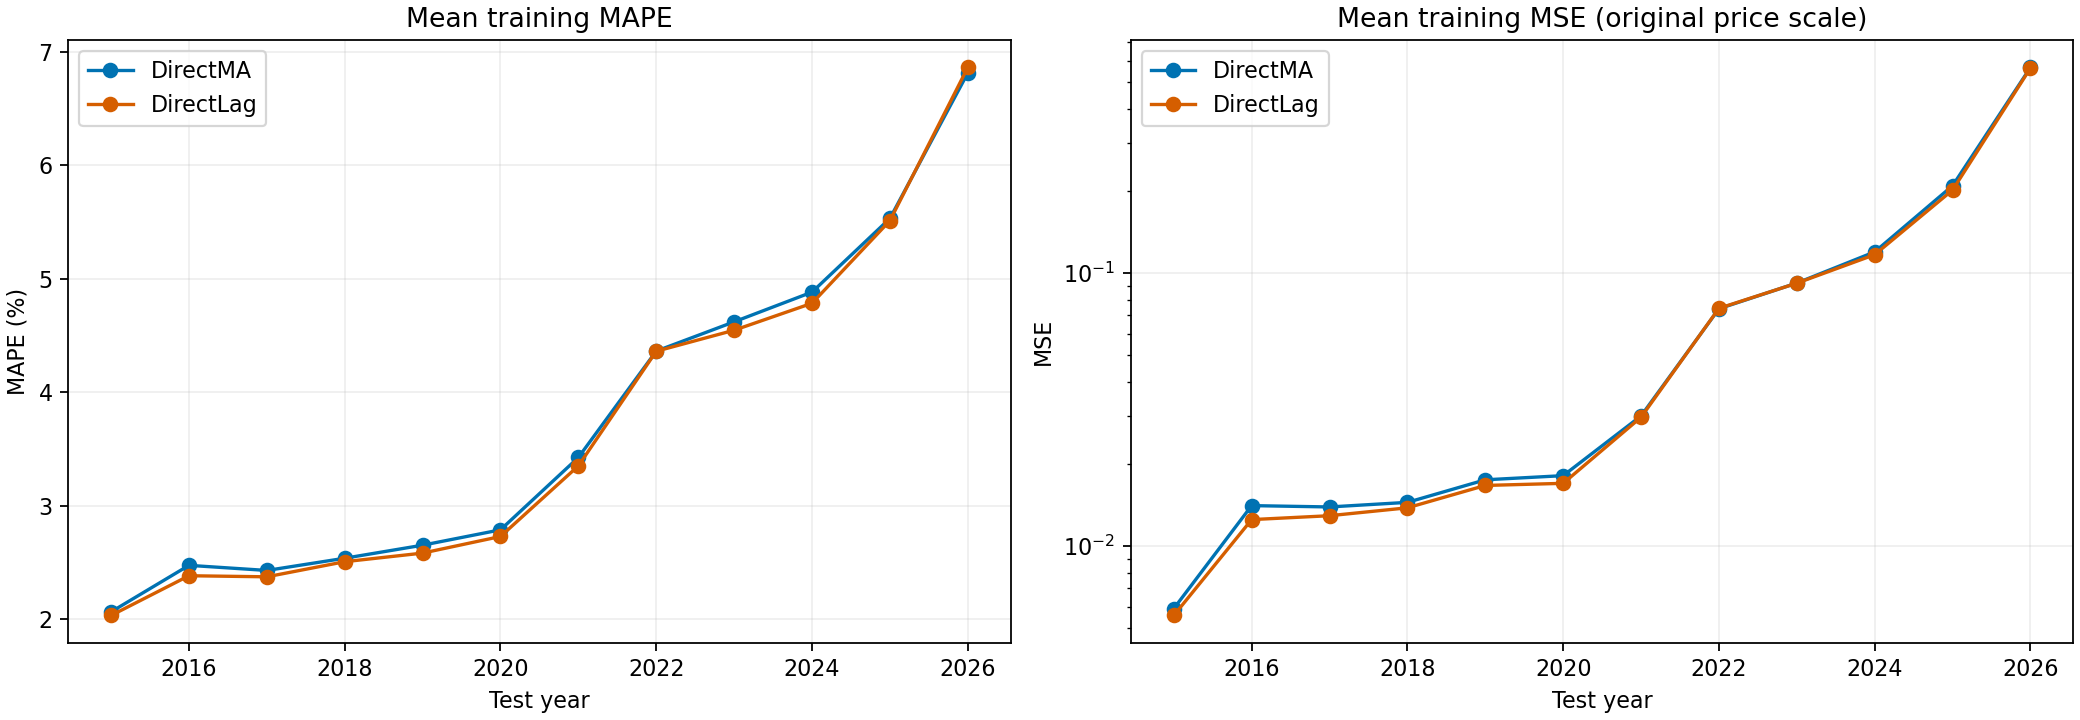

* 2026 is partial through the source data end date.


In [4]:
colors={'DirectMA':'#0072B2','DirectLag':'#D55E00'}
fig,axes=plt.subplots(2,1,figsize=(13,8),constrained_layout=True)
for model in order:
    axes[0].errorbar(annual_mean.index,annual_mean[model],yerr=annual_std[model],marker='o',capsize=4,color=colors[model],label=model)
axes[0].set(title='Direct inputs: MA deviation vs lag return | 100 epochs | 10 seeds',ylabel='Test MAPE (%)'); axes[0].legend()
axes[1].bar(paired_summary.index,paired_summary['mean'],color=np.where(paired_summary['mean']<0,'#009E73','#D55E00'))
axes[1].axhline(0,color='black',lw=.8)
axes[1].set(title='DirectLag minus DirectMA | Negative means lag returns improve',ylabel='MAPE difference (percentage points)',xlabel='Test year')
for ax in axes:
    ax.set_xticks(annual_mean.index); ax.set_xticklabels([str(y) if y!=2026 else '2026*' for y in annual_mean.index]); ax.grid(alpha=.2)
fig.savefig(OUT/'definition_comparison.png',dpi=160); plt.close(fig); display(Image(filename=str(OUT/'definition_comparison.png')))
fig,axes=plt.subplots(1,2,figsize=(13,4.5),constrained_layout=True)
for model in order:
    g=annual_train.xs(model,level='Model')
    axes[0].plot(g.index,g.MAPE,marker='o',color=colors[model],label=model)
    axes[1].plot(g.index,g.MSE,marker='o',color=colors[model],label=model)
axes[0].set(title='Mean training MAPE',ylabel='MAPE (%)'); axes[1].set(title='Mean training MSE (original price scale)',ylabel='MSE',yscale='log')
for ax in axes: ax.grid(alpha=.2); ax.legend(); ax.set_xlabel('Test year')
fig.savefig(OUT/'training_comparison.png',dpi=160); plt.close(fig); display(Image(filename=str(OUT/'training_comparison.png')))
print('* 2026 is partial through the source data end date.')


## 两种变化率定义的比较结论

| 年份 | 相对滚动均价DirectMA | 相对5/20期前DirectLag | Lag−MA（百分点） |
|---|---:|---:|---:|
|2015|10.7671%|10.8177%|+0.0506|
|2016|7.2286%|6.1065%|-1.1221|
|2017|13.0250%|12.3578%|-0.6673|
|2018|7.4316%|7.5356%|+0.1039|
|2019|8.3907%|8.5623%|+0.1717|
|2020|15.9227%|17.2518%|+1.3291|
|2021|8.0462%|7.4651%|-0.5811|
|2022|30.4248%|31.2412%|+0.8164|
|2023|12.4883%|13.2793%|+0.7909|
|2024|8.0795%|8.1010%|+0.0215|
|2025|17.2946%|17.3117%|+0.0171|
|2026（部分）|8.0915%|7.4475%|-0.6440|

2015—2025完整年份等权平均：DirectMA 12.6454%，DirectLag 12.7300%，均价定义平均低0.0846个百分点。含2026部分年份时分别为12.2659%与12.2898%，只差0.0239个百分点。两者整体效果接近，不能仅凭这么小的均值差认定稳定优势。

DirectMA在8个年份均值更低；DirectLag在2016、2017、2021、2026四年均值更低。年度均值胜负不等于所有种子均占优：例如2018年DirectLag在7/10个种子中改善，但平均MAPE仍略高。种子配对差和改善次数已列于上表输出及CSV。

差异较大的年份：2016年DirectLag改善1.1221个百分点；2020年DirectMA改善1.3291个百分点。2024、2025几乎持平。2022年两种定义均出现约30%—31%的共同误差峰值；更换定义没有消除该现象。

年度均价模型已逐日复现上一节全部年度/种子结果；滞后变化率模型的2020年结果也复现旧十种子实验。2026数据仅截至7月23日，不完整年度单列。训练MSE、训练MAPE、年度种子标准差、配对比较和两套权重保存在 `results/mlp_direct_definition_11`。


---

## 结论   
在大多数年份,股价的涨跌表示方法,并没有太多的差别.  
以10年,10个随机种子,Base的MAPE为12.66%,DirectMA为12.64%,DirectLag为12.73%.  
从数据上来看,加入滚动变化率更好一些.但是对于20,22年仍然有较大偏移.无法解释.主要的信息仍然在宏观变量上.

---

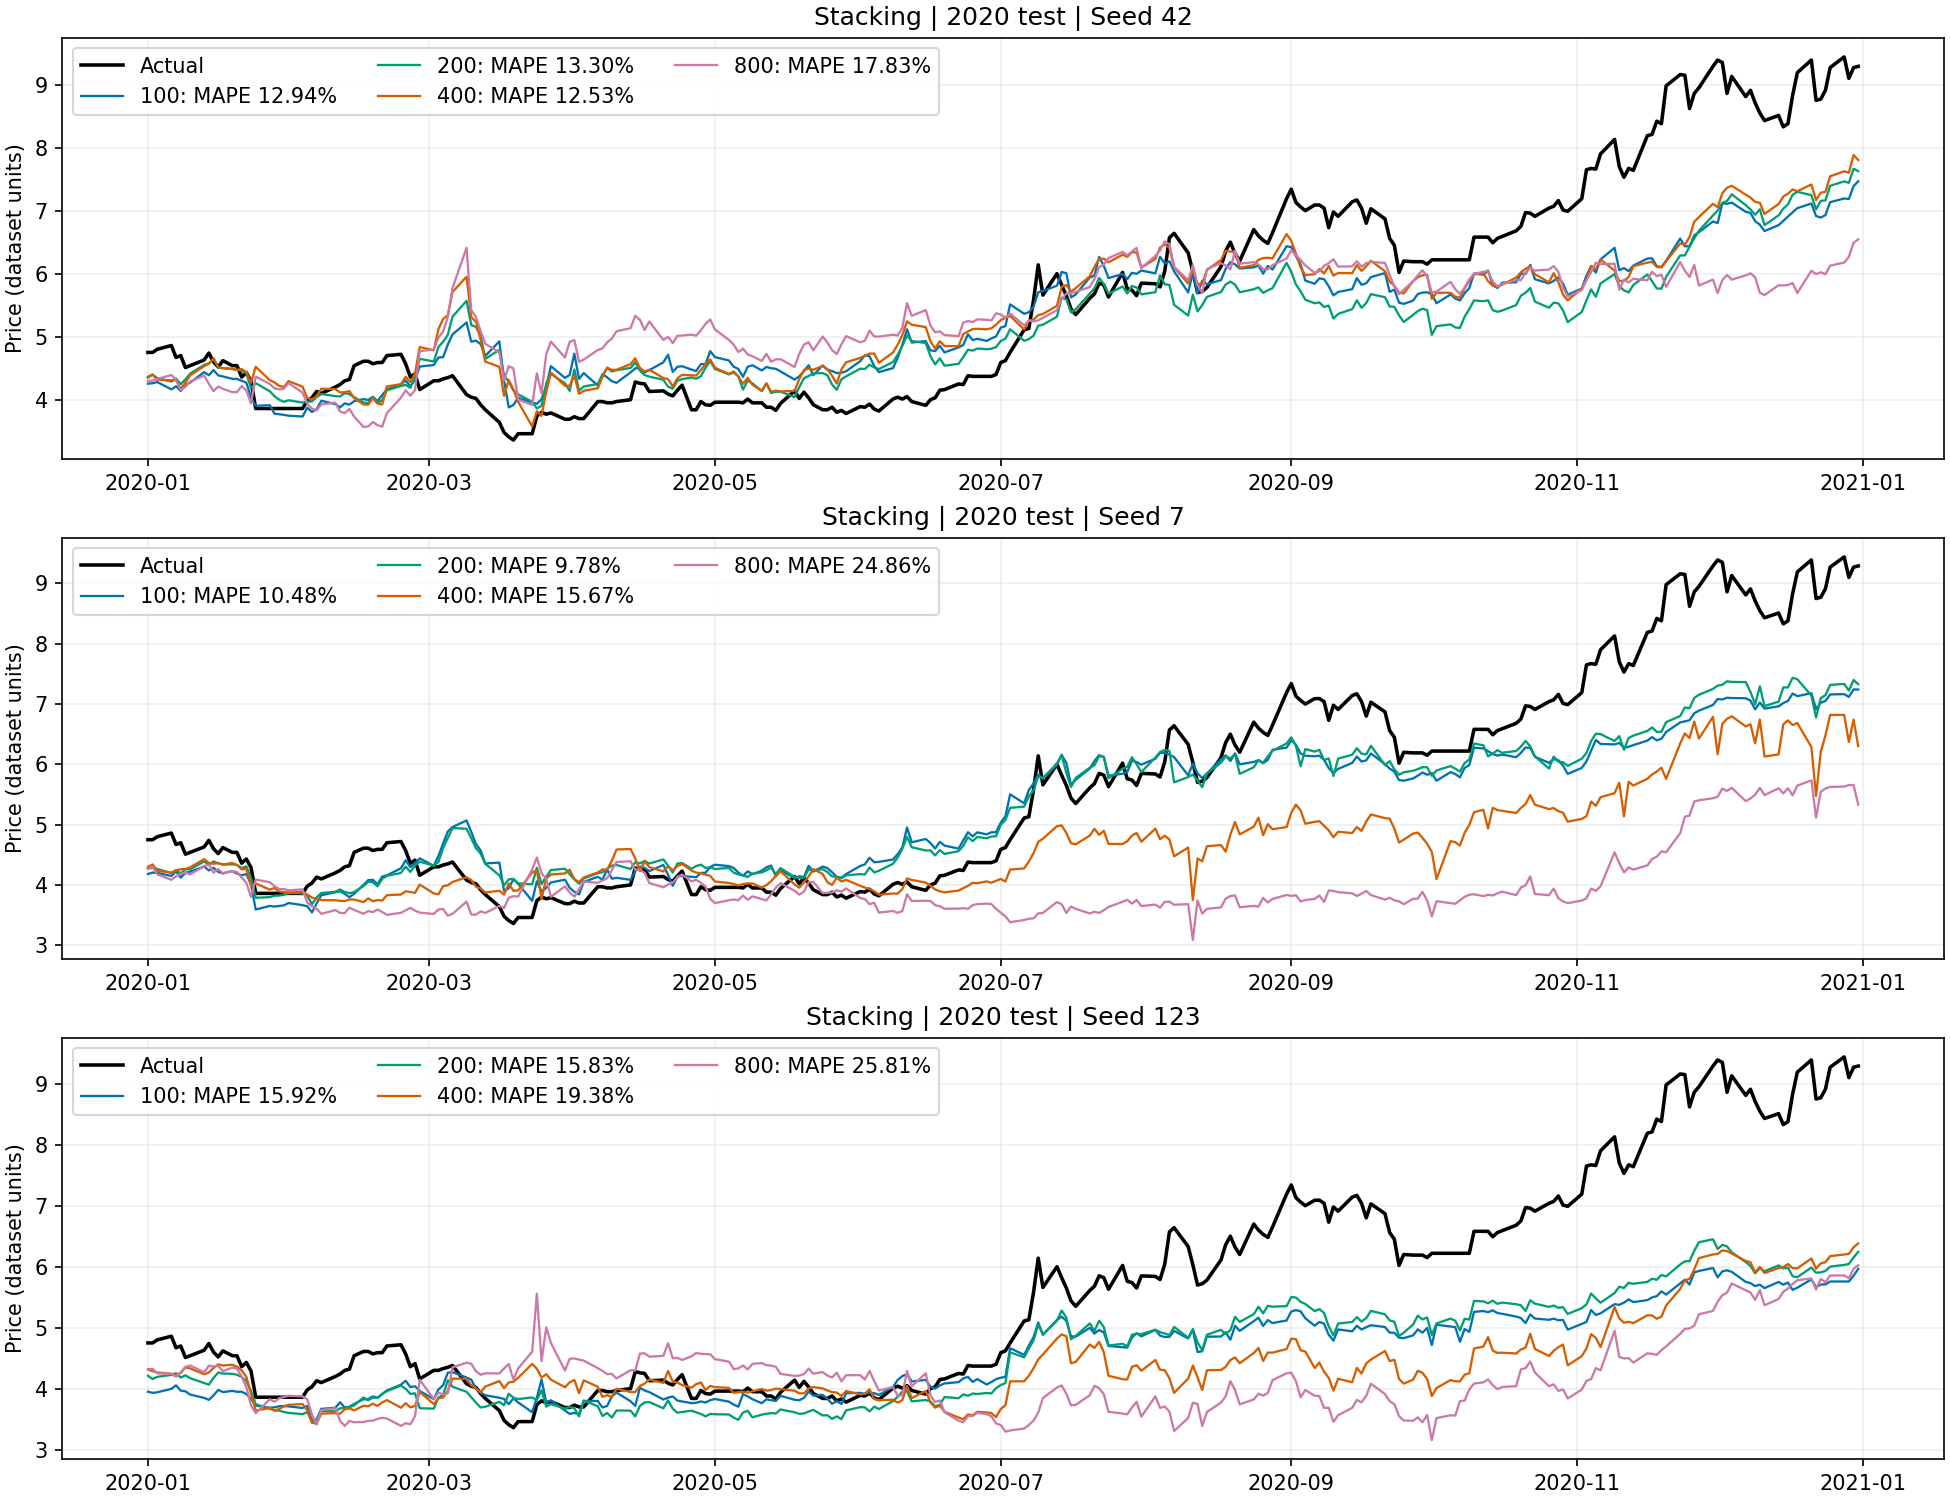

从这张图我们看出,同样的轮数,由于不同的种子,在之前拟合的好但是未必适用于现在的情况.如果我们再次加入验证集,让验证集合选一个最好的种子,进行外推,这样可以吗?

# 2020年前三个月验证选种子：单阶段DirectMA、100轮、五个种子

模型：原7变量＋金铜相对5/20期滚动均价涨幅，共11项输入；单阶段MLP，隐藏层16→32、ReLU、Adam学习率0.01、全批量、100轮。种子预先固定42、7、123、2024、2025；均价包含当日、窗口按原始记录计数。目标仍为原数据同日股价，不是次日预测。

1. 训练：2019-12-31及以前，保留上一实验共同剔除最初20条记录的口径；标准化仅拟合训练集。
2. 先展示五个模型2020年的预测，灰色区域为验证期。全年的展示只供事后说明，不参与程序选种子。
3. 验证：2020-01-01至2020-03-31，以验证MAPE最低者胜出；精确并列时按预先给定种子顺序。保存选择记录后，再计算后续测试误差。
4. 测试：2020-04-01至2020-12-31。锁定选中的模型，**不把验证集加入训练、不重新训练、不根据4—12月结果改选**。其它种子测试结果只作事后对照。

这是验证“选初始化”的实验，不能找到对所有未来时期最优的种子。由于此前已反复分析2020年，本节属于历史回放，而非全新盲测。没有月份内滚动重训练；“滚动”指输入的均价指标。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_SEEDVAL_OUT',str(ROOT/'results/mlp_seed_validation_2020_11'))); OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123,2024,2025]; EPOCHS=100; LR=0.01
torch.set_num_threads(1); torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'; d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy(); assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index.year<=2020]; BASE=list(raw.columns); assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); DIRECT=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_ma_deviation{k}'; DIRECT.append(name)
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
COLS=BASE+DIRECT
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())&(x.index>=raw.index[20])
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index<'2020-01-01']; va=x.index[(x.index>='2020-01-01')&(x.index<'2020-04-01')]; te=x.index[(x.index>='2020-04-01')&(x.index<'2021-01-01')]
whole=x.index[x.index.year==2020]
assert len(tr)==2034 and len(va)+len(te)==271 and tr.max()<va.min() and va.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(i),Start=str(i.min().date()),End=str(i.max().date())) for s,i in [('Train',tr),('Validation',va),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False); display(splits)
config=dict(seeds=SEEDS,epochs=EPOCHS,hidden=[16,32],features=COLS,activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',selection='minimum Jan-Mar 2020 MAPE; ties by seed list order',refit=False,target='same-date original price',ma_includes_current=True,common_warmup_records=20,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
sx=StandardScaler().fit(x.loc[tr,COLS]); sy=StandardScaler().fit(y.loc[tr].to_numpy().reshape(-1,1))
xt=torch.tensor(sx.transform(x.loc[tr,COLS]),dtype=torch.float32); yt=torch.tensor(sy.transform(y.loc[tr].to_numpy().reshape(-1,1)),dtype=torch.float32)


,Split,N,Start,End
0,Train,2034,2012-06-06,2019-12-31
1,Validation,67,2020-01-01,2020-03-31
2,Test,204,2020-04-01,2020-12-31


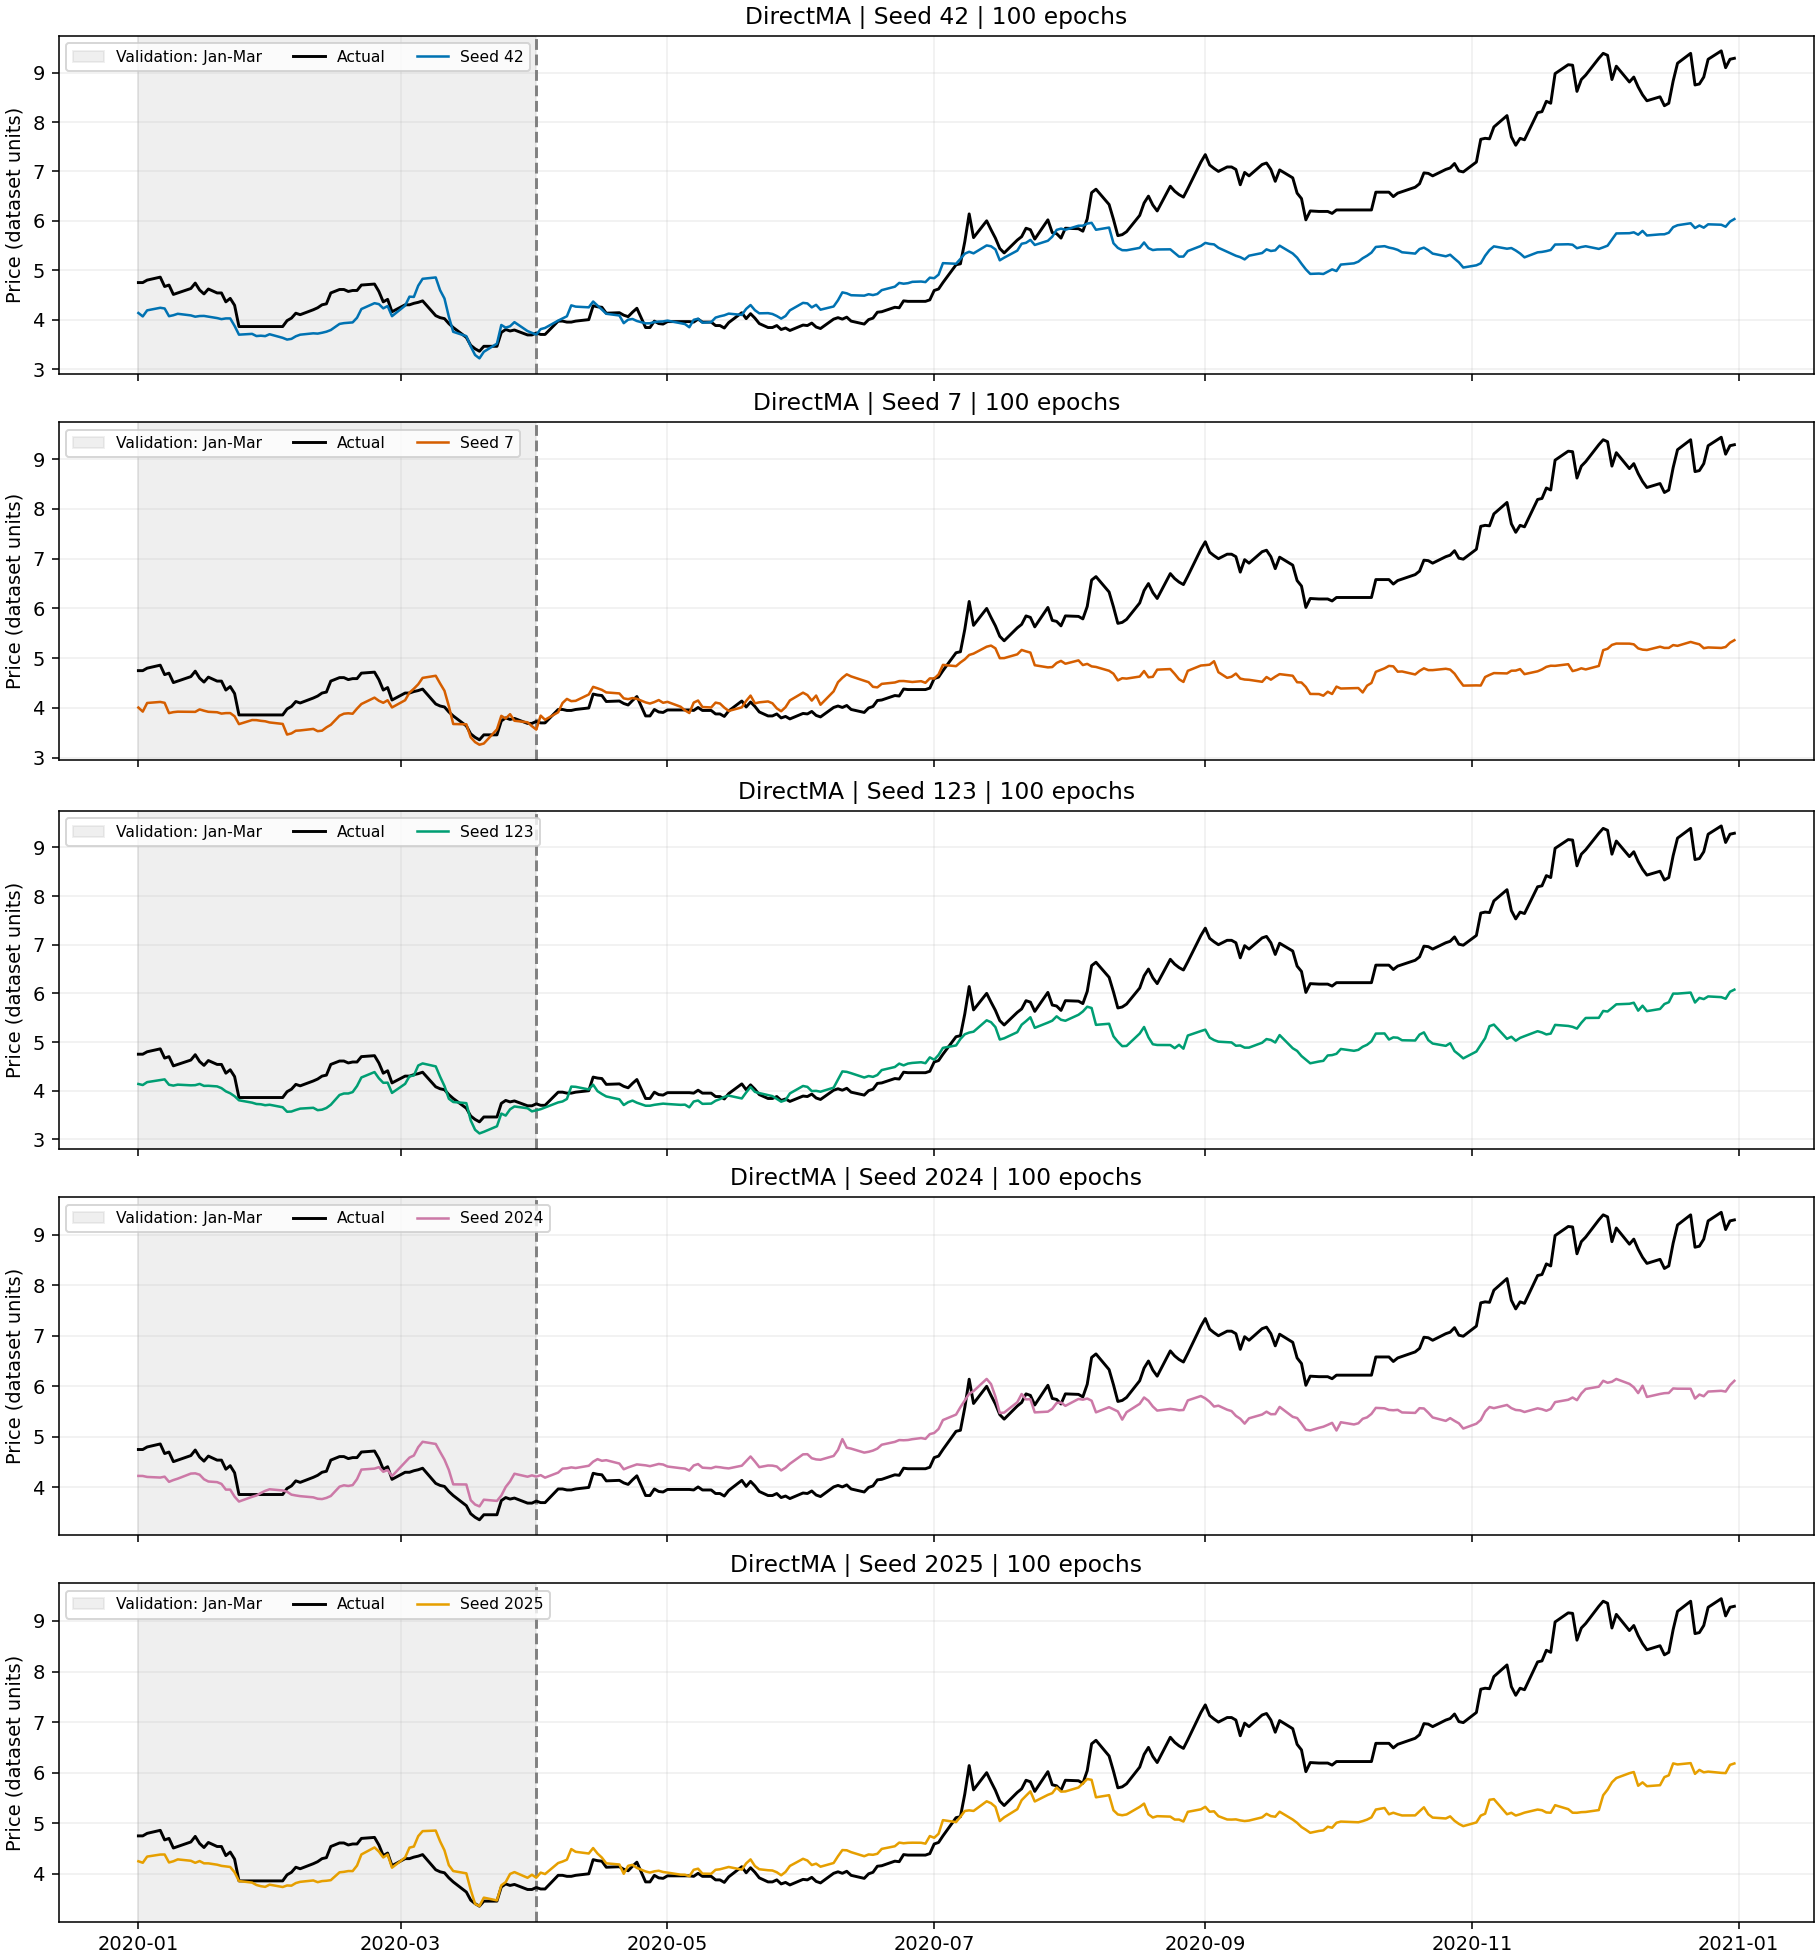

复核通过：五个种子的预测与此前2020年DirectMA实验一致。


In [2]:
history=[]; preds={}; models={}
for seed in SEEDS:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    optimizer=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); optimizer.zero_grad(); loss=((model(xt)-yt)**2).mean(); assert torch.isfinite(loss)
        loss.backward(); optimizer.step(); model.eval()
        with torch.no_grad(): z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel(); mse=np.mean((p-y.loc[tr].to_numpy())**2)
        history.append(dict(Seed=seed,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    with torch.no_grad(): z=model(torch.tensor(sx.transform(x[COLS]),dtype=torch.float32)).numpy()
    preds[seed]=pd.Series(sy.inverse_transform(z).ravel(),index=x.index); models[seed]=model
    assert np.isfinite(preds[seed]).all()
    torch.save(dict(state_dict=model.state_dict(),seed=seed,epochs=EPOCHS,features=COLS,sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'DirectMA_seed{seed}.pt')
pd.DataFrame(history).to_csv(OUT/'training_history.csv',index=False)
predictions=pd.concat([pd.DataFrame(dict(Date=x.index,Seed=seed,Actual=y.to_numpy(),Predicted=preds[seed].to_numpy(),Split=np.where(x.index<'2020-01-01','Train',np.where(x.index<'2020-04-01','Validation','Test')))) for seed in SEEDS],ignore_index=True)
predictions.to_csv(OUT/'predictions.csv',index=False)
# 复现此前2020年DirectMA，按float32往返精度核对。
prior=OUT.parent/'mlp_direct_definition_11/predictions.csv'
if prior.exists():
    old=pd.read_csv(prior,parse_dates=['Date']); old=old[(old.Year==2020)&(old.Model=='DirectMA')&old.Seed.isin(SEEDS)]
    check=old.merge(predictions,on=['Date','Seed'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==len(predictions)
    assert np.array_equal(check.Predicted_old.to_numpy(dtype=np.float32),check.Predicted_new.to_numpy(dtype=np.float32))
    print('复核通过：五个种子的预测与此前2020年DirectMA实验一致。')
# 按请求先展示五条全年曲线，此时尚未用后续测试误差选种子。
colors=dict(zip(SEEDS,['#0072B2','#D55E00','#009E73','#CC79A7','#E69F00']))
fig,axes=plt.subplots(5,1,figsize=(13,14),sharex=True,constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.axvspan(pd.Timestamp('2020-01-01'),pd.Timestamp('2020-04-01'),color='#999999',alpha=.15,label='Validation: Jan-Mar')
    ax.axvline(pd.Timestamp('2020-04-01'),color='gray',ls='--')
    ax.plot(whole,y.loc[whole],color='black',lw=1.5,label='Actual')
    ax.plot(whole,preds[seed].loc[whole],color=colors[seed],lw=1.3,label=f'Seed {seed}')
    ax.set(title=f'DirectMA | Seed {seed} | 100 epochs',ylabel='Price (dataset units)'); ax.grid(alpha=.2); ax.legend(loc='upper left',ncol=3,fontsize=8)
fig.savefig(OUT/'five_seed_predictions.png',dpi=140);plt.close(fig);display(Image(filename=str(OUT/'five_seed_predictions.png')))


## 只用第一季度选择并锁定种子

依次计算各候选在2020年1—3月的MAPE，按低到高排序，选取第一名。这个步骤不读取4—12月误差；保存选择记录后再评估后续表现。


,Validation_rank,Seed,MAPE,Selected
0,1,2025,6.6502,True
1,2,123,8.1131,False
2,3,42,8.1962,False
3,4,2024,8.5178,False
4,5,7,9.2774,False


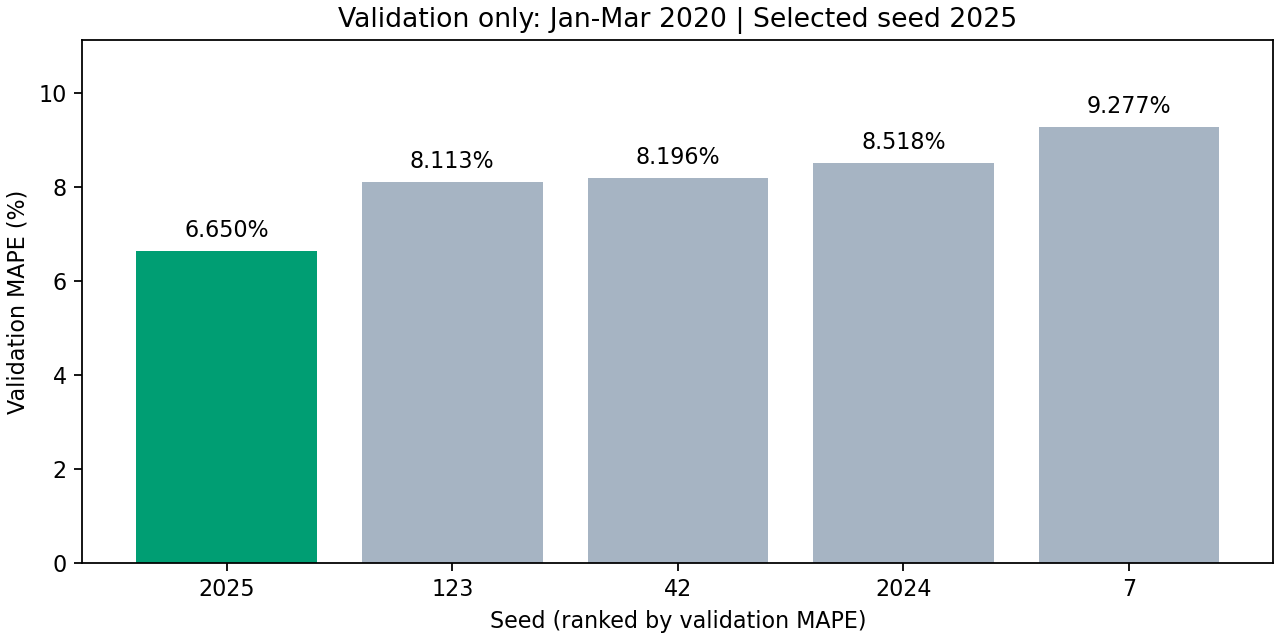

按验证MAPE锁定 seed 2025，不重新训练。


In [3]:
def metrics_at(seed,idx):
    a=y.loc[idx].to_numpy(); p=preds[seed].loc[idx].to_numpy(); err=p-a
    return dict(N=len(idx),MAPE=100*np.mean(np.abs(err)/np.abs(a)),MSE=np.mean(err**2))
validation=pd.DataFrame([dict(Seed=seed,Candidate_order=i,**metrics_at(seed,va)) for i,seed in enumerate(SEEDS)])
validation=validation.sort_values(['MAPE','Candidate_order']).reset_index(drop=True)
validation.insert(0,'Validation_rank',np.arange(1,len(validation)+1))
selected_seed=int(validation.iloc[0].Seed)
validation['Selected']=validation.Seed.eq(selected_seed)
validation.to_csv(OUT/'validation_ranking.csv',index=False)
selection=dict(selected_seed=selected_seed,criterion='Jan-Mar 2020 MAPE only',validation_mape=float(validation.iloc[0].MAPE),validation_start=str(va.min().date()),validation_end=str(va.max().date()),candidate_order=SEEDS,epochs=EPOCHS,refit=False)
(OUT/'selection.json').write_text(json.dumps(selection,ensure_ascii=False,indent=2))
print(f'按验证MAPE锁定 seed {selected_seed}，不重新训练。'); display(validation[['Validation_rank','Seed','MAPE','Selected']].round(4))
fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True)
bars=ax.bar(validation.Seed.astype(str),validation.MAPE,color=['#009E73' if s==selected_seed else '#a6b4c3' for s in validation.Seed])
ax.bar_label(bars,fmt='%.3f%%',padding=4);ax.margins(y=.2)
ax.set(title=f'Validation only: Jan-Mar 2020 | Selected seed {selected_seed}',xlabel='Seed (ranked by validation MAPE)',ylabel='Validation MAPE (%)')
fig.savefig(OUT/'validation_selection.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'validation_selection.png')))


## 锁定后评估2020年4—12月

下表展示五个候选的后续表现，用于回顾验证排名是否延续。所选种子保持不变；后续测试期表现最好的种子只是事后对照，不能据此改选。


Split,Test,Train,Validation,Validation_rank,Test_rank,Selected
Seed,,,,,,
42,15.9037,3.0182,8.1962,3,1,False
7,21.7190,2.9150,9.2774,5,5,False
123,17.7512,2.6869,8.1131,2,4,False
2024,17.4677,2.6874,8.5178,4,3,False
2025,16.9769,2.7897,6.6502,1,2,True


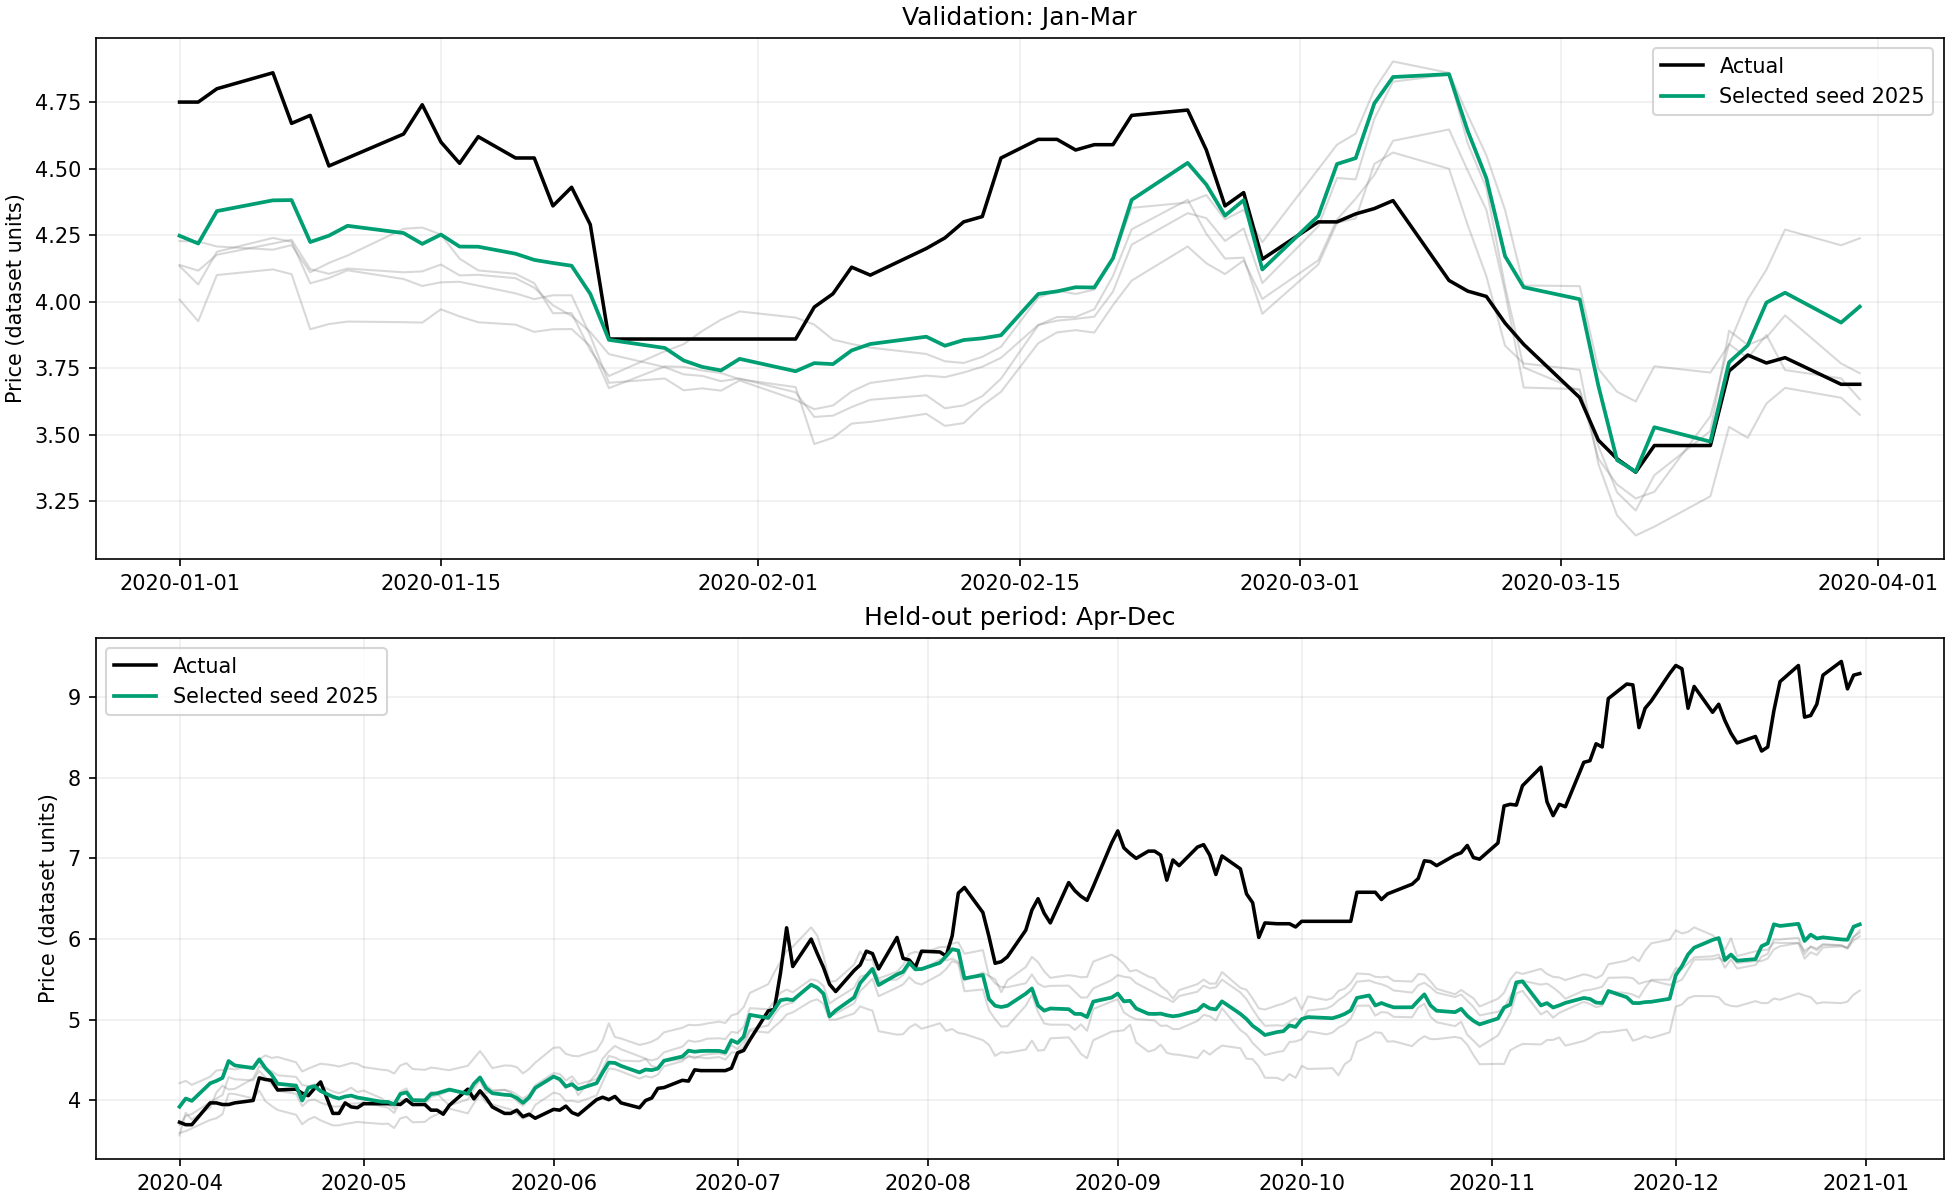

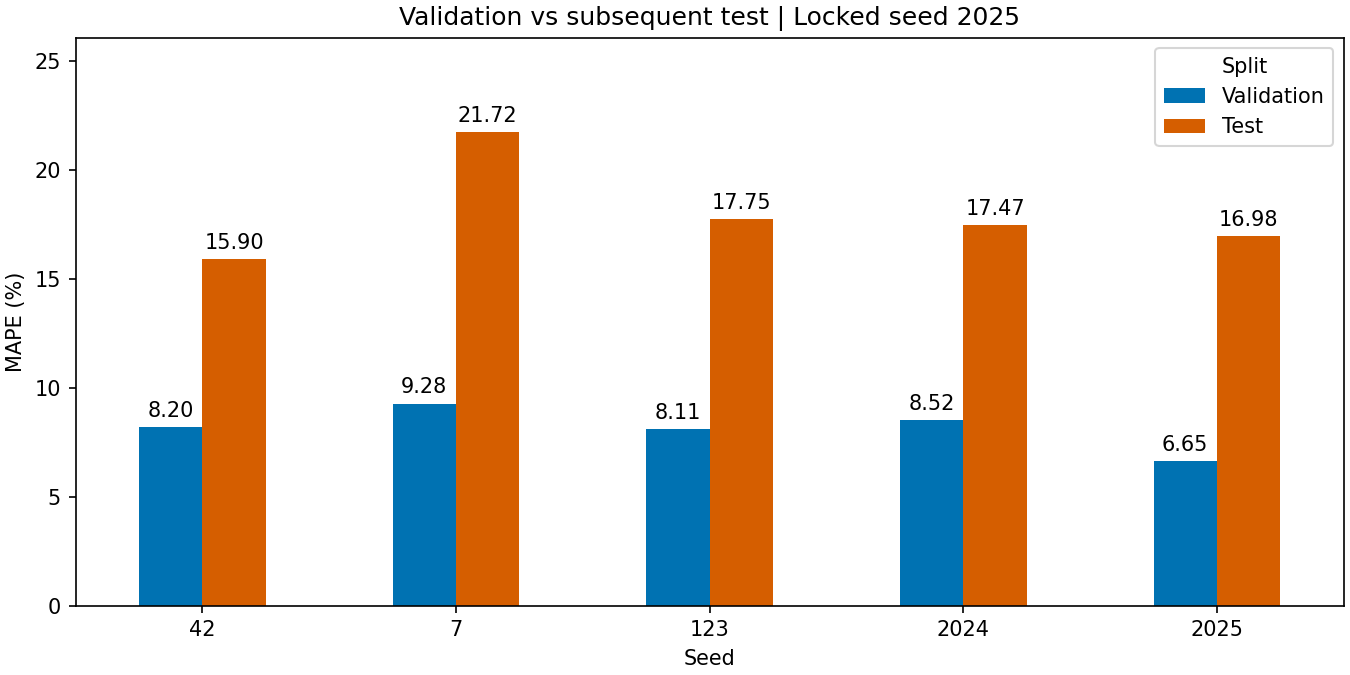

验证选中seed 2025；4—12月MAPE=16.9769%，五种子MAPE均值=17.9637%。


In [4]:
locked=json.loads((OUT/'selection.json').read_text()); assert selected_seed==locked['selected_seed']
metrics=pd.DataFrame([dict(Seed=seed,Split=split,**metrics_at(seed,idx)) for seed in SEEDS for split,idx in [('Train',tr),('Validation',va),('Test',te)]])
metrics.to_csv(OUT/'metrics.csv',index=False)
comparison=metrics.pivot(index='Seed',columns='Split',values='MAPE').reindex(SEEDS)
comparison['Validation_rank']=comparison.Validation.rank(method='first').astype(int)
comparison['Test_rank']=comparison.Test.rank(method='min').astype(int)
comparison['Selected']=comparison.index==selected_seed
comparison.to_csv(OUT/'comparison.csv')
display(comparison.round(4))
selected_test=float(comparison.loc[selected_seed,'Test']); test_mean=float(comparison.Test.mean())
result=dict(selected_seed=selected_seed,selected_validation_mape=float(comparison.loc[selected_seed,'Validation']),selected_test_mape=selected_test,selected_test_rank=int(comparison.loc[selected_seed,'Test_rank']),five_seed_mean_test_mape=test_mean,five_seed_test_sd=float(comparison.Test.std()),selected_minus_seed_mean_pp=selected_test-test_mean,refit=False)
(OUT/'evaluation.json').write_text(json.dumps(result,ensure_ascii=False,indent=2))
print(f'验证选中seed {selected_seed}；4—12月MAPE={selected_test:.4f}%，五种子MAPE均值={test_mean:.4f}%。')
fig,axes=plt.subplots(2,1,figsize=(13,8),constrained_layout=True)
for ax,idx,title in [(axes[0],va,'Validation: Jan-Mar'),(axes[1],te,'Held-out period: Apr-Dec')]:
    for seed in SEEDS:
        if seed!=selected_seed:ax.plot(idx,preds[seed].loc[idx],color='gray',alpha=.3,lw=1)
    ax.plot(idx,y.loc[idx],color='black',lw=1.7,label='Actual')
    ax.plot(idx,preds[selected_seed].loc[idx],color='#009E73',lw=1.8,label=f'Selected seed {selected_seed}')
    ax.set(title=title,ylabel='Price (dataset units)');ax.legend();ax.grid(alpha=.2)
fig.savefig(OUT/'selected_prediction.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'selected_prediction.png')))
fig,ax=plt.subplots(figsize=(9,4.5),constrained_layout=True)
comparison[['Validation','Test']].plot.bar(ax=ax,rot=0,color=['#0072B2','#D55E00'])
ax.set(title=f'Validation vs subsequent test | Locked seed {selected_seed}',ylabel='MAPE (%)');ax.margins(y=.2)
for c in ax.containers:ax.bar_label(c,fmt='%.2f',padding=3)
fig.savefig(OUT/'validation_vs_test.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'validation_vs_test.png')))


## 第一季度验证选种子的结果

| 种子 | 验证MAPE（1—3月） | 验证排名 | 后续MAPE（4—12月） | 后续排名 | 选择 |
|---|---:|---:|---:|---:|---|
|42|8.1962%|3|15.9037%|1||
|7|9.2774%|5|21.7190%|5||
|123|8.1131%|2|17.7512%|4||
|2024|8.5178%|4|17.4677%|3||
|2025|6.6502%|1|16.9769%|2|验证选中|

**按预定规则选择2025**：只用第一季度的6.6502%验证MAPE，锁定权重，未重新训练。后续4—12月MAPE为16.9769%，比五个种子的平均测试MAPE 17.9637%低0.9868个百分点，但比事后最优seed42高1.0732个百分点。

因此，本次验证筛选优于五候选平均表现，却未选中后续最好的模型。种子123验证排名第二、后续第四，也说明验证排名未完全保持。第一季度只覆盖一个短时期，不能保证代表后续行情；不能把2025称为普遍最优种子，也不能根据后续结果把选择改成42。

全年预测图中1—3月是验证集，不能再把全年MAPE称为独立测试指标。灰色候选曲线和其它种子后续MAPE仅用于事后展示。此前已反复分析过2020年，所以这一实验应理解为历史回放；将来的严格检验需固定规则后评估未参与开发的数据。

五个种子的预测已复现此前DirectMA实验；先保存验证排名和selection.json，再计算后续测试结果。完整输出位于 `results/mlp_seed_validation_2020_11`。


---

如果用一层模型,那么这种选种子的方式没有太大效果.  
两层模型在种子7下效果最好.假设我们重新打乱选10个种子,看看两层模型是否能通过同样的方法找到近似最优的.  
在10年的测试中,两层模型略逊于一层模型,但是100轮简单,收敛快,如果能推广好,找到较好的种子,那么效果应该会更好.